# Analysis 1A: OOD transfer boundary in unseen cellular contexts

This notebook implements the locked **Analysis 1A** plan using the existing `cell_split1`-`cell_split5` test-prediction HDF5 files generated by `DEPICT_PredictedDGE_SeparatedBySplitType-2.ipynb`.

**Primary endpoint:** for each held-out test cell, mean per-perturbation Delta PCC across the full observed test mixture, regressed/correlated with nearest-training-cell baseline-control similarity.

**Secondary checks:** Delta R2, DGE MSE, model gain over the naive baseline, centroid+variance cosine similarity, top-k mean similarity, fixed contexts (10 uM/6 h, 10 uM/24 h, and <0.5 uM/24 h), and optional equal-context pooled Delta PCC.

The notebook is analysis-only: it does not retrain DEPICT or rerun inference.

In [1]:
from __future__ import annotations

import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Configuration

Set the file paths below. The default locations match the extraction notebook. `adata_path` must be the same source AnnData used for prediction extraction, because Analysis 1A recomputes normalized DMSO control centroids from it.

In [ ]:
PROJECT_ROOT = Path("~/DEPICT")
MAIN_WORK_DIR = PROJECT_ROOT / "Code/downstream_analysis_code/TransferabilityUnseenCell"

CONFIG = {
    "adata_path": PROJECT_ROOT / "Data/FinalData/adataAfterClean.h5ad",
    "prediction_root": MAIN_WORK_DIR / "predicted_dge",
    "output_dir": MAIN_WORK_DIR / "a1_ood_similarity",
    "cell_splits": [f"cell_split{i}" for i in range(1, 6)],
    "expected_n_genes": 978,
    "top_k_train_cells": 3,
    "min_test_perturbations_warning": 20,
    "min_context_perturbations": 20,
    "n_bootstrap": 2000,
    "random_seed": 66,
    "epsilon": 1e-8,
    # Use exact observed dose/time values. This follows the locked fixed-context addendum.
    "dose_tolerance": 1e-6,
    "time_tolerance": 1e-6,
}

OUT = Path(CONFIG["output_dir"])
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
MANIFEST_DIR = OUT / "manifests"
for p in (OUT, TABLE_DIR, FIG_DIR, MANIFEST_DIR):
    p.mkdir(parents=True, exist_ok=True)

CONFIG


{'adata_path': PosixPath('/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/data/whole_data_Jul11/adataAfterClean.h5ad'),
 'prediction_root': PosixPath('/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/predicted_dge'),
 'output_dir': PosixPath('/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/a1_ood_similarity'),
 'cell_splits': ['cell_split1',
  'cell_split2',
  'cell_split3',
  'cell_split4',
  'cell_split5'],
 'expected_n_genes': 978,
 'top_k_train_cells': 3,
 'min_test_perturbations_warning': 20,
 'min_context_perturbations': 20,
 'n_bootstrap': 2000,
 'random_seed': 66,
 'epsilon': 1e-08,
 'dose_tolerance': 1e-06,
 'time_tolerance': 1e-06}

## 2. Reproducibility helpers and required-input audit

The prediction HDF5 file must contain `cell_id`, `dose`, `pert_time`, `observed_dge`, and `predicted_dge`. The test rows are preserved exactly from the inference extractor. The AnnData must contain `control`, `cell_id`, and all five cell-split columns.

In [3]:
def require(condition: bool, message: str):
    if not condition:
        raise RuntimeError(message)

def decode_h5_strings(arr):
    arr = np.asarray(arr)
    if arr.dtype.kind == "S":
        return np.char.decode(arr, "utf-8")
    if arr.dtype.kind == "O":
        return np.asarray([x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else str(x) for x in arr], dtype=object)
    return arr.astype(str)


def hash_sequence(values):
    """Deterministic SHA-256 hash for ordered identifiers such as var_names."""
    import hashlib
    digest = hashlib.sha256()
    for value in values:
        encoded = str(value).encode("utf-8")
        digest.update(len(encoded).to_bytes(8, byteorder="big"))
        digest.update(encoded)
    return digest.hexdigest()

def as_text_attr(value):
    if isinstance(value, (bytes, bytearray)):
        return value.decode("utf-8")
    return str(value)

def h5_path_for_split(split_type: str) -> Path:
    return Path(CONFIG["prediction_root"]) / split_type / "predicted_dge_test.h5"

def save_table(df: pd.DataFrame, stem: str, index: bool = False):
    csv = TABLE_DIR / f"{stem}.csv"
    df.to_csv(csv, index=index)
    try:
        df.to_parquet(TABLE_DIR / f"{stem}.parquet", index=index)
    except Exception as exc:
        print(f"Parquet not written for {stem}: {exc!r}")
    return csv

def percentile_ci(values, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    return np.quantile(values, [alpha/2, 1-alpha/2])

require(Path(CONFIG["adata_path"]).exists(), f"AnnData not found: {CONFIG['adata_path']}")
for split in CONFIG["cell_splits"]:
    require(h5_path_for_split(split).exists(), f"Missing prediction HDF5 for {split}: {h5_path_for_split(split)}")

print("Input file audit passed.")


Input file audit passed.


## 3. Load AnnData and reconstruct training-time normalization

The extraction notebook applies `scanpy.pp.normalize_total(adata)` with default `target_sum=None`; the same operation is repeated here before computing cell-control centroids and variances.

In [4]:
adata = sc.read(CONFIG["adata_path"])
require(adata.n_vars == CONFIG["expected_n_genes"], f"Expected {CONFIG['expected_n_genes']} genes; found {adata.n_vars}.")
for col in ["control", "cell_id", *CONFIG["cell_splits"]]:
    require(col in adata.obs.columns, f"AnnData missing required obs column: {col}")
require(adata.obs_names.is_unique, "AnnData obs_names must be unique.")

print("Applying training-time total normalization...")
sc.pp.normalize_total(adata)

control_mask = adata.obs["control"].to_numpy() == 1
require(control_mask.any(), "No control rows identified by control == 1.")
control_cells = adata.obs.loc[control_mask, "cell_id"].astype(str).to_numpy()
control_X = adata.X[control_mask]
control_X = control_X.toarray() if hasattr(control_X, "toarray") else np.asarray(control_X)
control_X = np.asarray(control_X, dtype=np.float32)

cell_control_summary = []
cell_centroids = {}
cell_variances = {}
for cell in np.unique(control_cells):
    Xc = control_X[control_cells == cell]
    cell_centroids[cell] = Xc.mean(axis=0, dtype=np.float32)
    cell_variances[cell] = Xc.var(axis=0, dtype=np.float32)
    cell_control_summary.append({
        "cell_id": cell,
        "n_control_rows": int(Xc.shape[0]),
        "control_total_mean": float(Xc.sum(axis=1).mean()),
        "control_total_sd": float(Xc.sum(axis=1).std(ddof=0)),
    })
cell_control_summary = pd.DataFrame(cell_control_summary).sort_values("cell_id").reset_index(drop=True)
save_table(cell_control_summary, "a1_control_cell_summary")
print(f"Loaded {adata.n_obs:,} rows, {adata.n_vars} genes, and {len(cell_centroids)} control-characterized cell lines.")
cell_control_summary.head()


Applying training-time total normalization...
Loaded 883,077 rows, 978 genes, and 82 control-characterized cell lines.


,cell_id,n_control_rows,control_total_mean,control_total_sd
0,A375,4235,8220.280273,0.001045
1,A549,3337,8220.281250,0.000494
2,A673,28,8220.281250,0.000185
3,AGS,17,8220.281250,0.000237
4,ASC,459,8220.281250,0.000379


## 4. Load extracted test predictions and calculate row-level performance

`Delta PCC` and `Delta R2` are calculated between predicted and observed DGE for each perturbation. DGE MSE is the mean squared error over the 978 genes. The naive baseline predicts perturbed expression as baseline, equivalent to predicting zero DGE. Therefore its DGE MSE is `mean(observed_dge^2)`, and its Delta R2 is computed against a zero DGE prediction. Delta PCC for the naive baseline is undefined because a zero vector has zero variance.

In [5]:
def safe_pearson_rows(A: np.ndarray, B: np.ndarray, eps: float = 1e-8, undefined_value: float = 0.0) -> np.ndarray:
    """Row-wise Pearson correlation, matching the extractor/prediction.py convention.

    When either DGE vector is constant, Pearson correlation is undefined. The
    extraction notebook records this case as 0.0; use the same convention here
    rather than dropping the perturbation from a cell-level average.
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    Ac = A - A.mean(axis=1, keepdims=True)
    Bc = B - B.mean(axis=1, keepdims=True)
    denom = np.sqrt((Ac * Ac).sum(axis=1) * (Bc * Bc).sum(axis=1))
    out = np.full(A.shape[0], float(undefined_value), dtype=float)
    valid = denom > eps
    out[valid] = (Ac[valid] * Bc[valid]).sum(axis=1) / denom[valid]
    return out

def rowwise_r2(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Row-wise R2 with sklearn's default force_finite convention.

    For constant observed DGE, sklearn.r2_score returns 1.0 for perfect
    predictions and 0.0 otherwise. This makes the analysis numerically aligned
    with the prediction-extraction notebook.
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    ss_res = ((y_true - y_pred) ** 2).sum(axis=1)
    centered = y_true - y_true.mean(axis=1, keepdims=True)
    ss_tot = (centered ** 2).sum(axis=1)
    out = np.empty(y_true.shape[0], dtype=float)
    nonconstant = ss_tot > eps
    out[nonconstant] = 1.0 - ss_res[nonconstant] / ss_tot[nonconstant]
    out[~nonconstant] = np.where(ss_res[~nonconstant] <= eps, 1.0, 0.0)
    return out

def read_fold_predictions(split_type: str) -> tuple[pd.DataFrame, dict]:
    path = h5_path_for_split(split_type)
    with h5py.File(path, "r") as h5:
        needed = {"cell_id", "dose", "pert_time", "observed_dge", "predicted_dge"}
        missing = needed.difference(h5.keys())
        require(not missing, f"{path} is missing datasets: {sorted(missing)}")
        attrs = {key: h5.attrs[key] for key in h5.attrs.keys()}
        # Validate extraction provenance when the attributes are available.
        if "subset" in attrs:
            require(as_text_attr(attrs["subset"]) == "test", f"{path} is not a test-set extraction.")
        if "split_type" in attrs:
            require(as_text_attr(attrs["split_type"]) == split_type, f"Split mismatch in {path}.")
        if "model_mode" in attrs:
            require(as_text_attr(attrs["model_mode"]) == "eval", f"{path} was not generated in model.eval() mode.")
        if "n_genes" in attrs:
            require(int(attrs["n_genes"]) == CONFIG["expected_n_genes"], f"Gene-count mismatch in {path}.")
        if "adata_var_names_hash_sha256" in attrs:
            require(as_text_attr(attrs["adata_var_names_hash_sha256"]) == hash_sequence(adata.var_names.astype(str)),
                    f"Gene ordering in {path} does not match the current AnnData var_names.")

        obs = np.asarray(h5["observed_dge"], dtype=np.float32)
        pred = np.asarray(h5["predicted_dge"], dtype=np.float32)
        require(obs.shape == pred.shape and obs.shape[1] == CONFIG["expected_n_genes"],
                f"Unexpected DGE matrix shapes in {path}: observed={obs.shape}, predicted={pred.shape}")
        data = {
            "split_type": split_type,
            "cell_id": decode_h5_strings(h5["cell_id"][:]),
            "dose": np.asarray(h5["dose"][:], dtype=float),
            "pert_time": np.asarray(h5["pert_time"][:], dtype=float),
            "delta_pcc": safe_pearson_rows(obs, pred, CONFIG["epsilon"]),
            "delta_r2": rowwise_r2(obs, pred),
            "dge_mse": ((obs - pred) ** 2).mean(axis=1),
            "naive_dge_mse": (obs ** 2).mean(axis=1),
            "naive_delta_r2": rowwise_r2(obs, np.zeros_like(obs)),
        }
        if "obs_name" in h5:
            data["obs_name"] = decode_h5_strings(h5["obs_name"][:])
        if "pert_iname" in h5:
            data["pert_iname"] = decode_h5_strings(h5["pert_iname"][:])
    df = pd.DataFrame(data)
    df["mse_gain_over_naive"] = df["naive_dge_mse"] - df["dge_mse"]
    df["delta_r2_gain_over_naive"] = df["delta_r2"] - df["naive_delta_r2"]
    return df, attrs

row_frames, prediction_attrs = [], {}
for split in CONFIG["cell_splits"]:
    df, attrs = read_fold_predictions(split)
    row_frames.append(df)
    prediction_attrs[split] = {k: (v.item() if hasattr(v, "item") else v) for k, v in attrs.items()}
    print(f"{split}: {len(df):,} test perturbations; {df['cell_id'].nunique()} held-out test cells.")

row_metrics = pd.concat(row_frames, ignore_index=True)
require(np.isfinite(row_metrics[["delta_pcc", "delta_r2", "dge_mse"]].to_numpy(dtype=float)).all(),
        "Non-finite row-level metrics detected after metric calculation.")
save_table(row_metrics, "a1_row_level_metrics")
row_metrics.head()


cell_split1: 12,510 test perturbations; 9 held-out test cells.
cell_split2: 25,742 test perturbations; 9 held-out test cells.
cell_split3: 156,258 test perturbations; 9 held-out test cells.
cell_split4: 137,725 test perturbations; 9 held-out test cells.
cell_split5: 86,370 test perturbations; 9 held-out test cells.


,split_type,cell_id,dose,pert_time,delta_pcc,delta_r2,dge_mse,naive_dge_mse,naive_delta_r2,obs_name,pert_iname,mse_gain_over_naive,delta_r2_gain_over_naive
0,cell_split1,MNEU.E,10.00,24.0,0.574285,0.309166,0.771520,1.116794,-8.637535e-14,LJP007_MNEU.E_24H_X1_B24:A03-2,vorinostat,0.345275,0.309166
1,cell_split1,MNEU.E,10.00,24.0,0.627443,0.307839,0.618677,0.893834,-2.471356e-13,LJP007_MNEU.E_24H_X1_B24:A04-2,tanespimycin,0.275157,0.307839
2,cell_split1,MNEU.E,10.00,24.0,0.635989,0.378014,0.480585,0.772662,-1.212364e-13,LJP007_MNEU.E_24H_X1_B24:A07-2,XMD-885,0.292077,0.378014
3,cell_split1,MNEU.E,3.33,24.0,0.428102,0.169917,0.788195,0.949538,-3.042011e-13,LJP007_MNEU.E_24H_X1_B24:A08-2,XMD-885,0.161343,0.169917
4,cell_split1,MNEU.E,1.11,24.0,0.690077,0.460907,0.529632,0.982451,-3.708145e-14,LJP007_MNEU.E_24H_X1_B24:A09-2,XMD-885,0.452819,0.460907


## 5. Define training and test cells, then calculate OOD similarity

Primary similarity is the **maximum Pearson correlation** between each held-out test-cell control centroid and any training-cell control centroid. Training cells are defined from rows whose fold label is `train`; this preserves the exact split partition used by the model.

Secondary descriptors: (1) mean similarity among the top-k nearest training cells; and (2) cosine similarity of `concat(mu_c, log(var_c + epsilon))`, which mirrors the centroid and variance information supplied to DEPICT.

In [6]:
def pearson_similarity_matrix(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    A = A - A.mean(axis=1, keepdims=True)
    B = B - B.mean(axis=1, keepdims=True)
    An = np.sqrt((A * A).sum(axis=1, keepdims=True))
    Bn = np.sqrt((B * B).sum(axis=1, keepdims=True))
    denom = An @ Bn.T
    out = np.full((A.shape[0], B.shape[0]), np.nan, dtype=float)
    valid = denom > eps
    out[valid] = (A @ B.T)[valid] / denom[valid]
    return out

def cosine_similarity_matrix(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    denom = np.sqrt((A * A).sum(axis=1, keepdims=True)) @ np.sqrt((B * B).sum(axis=1, keepdims=True)).T
    out = np.full((A.shape[0], B.shape[0]), np.nan, dtype=float)
    valid = denom > eps
    out[valid] = (A @ B.T)[valid] / denom[valid]
    return out

def training_and_test_cells(split_type: str):
    labels = adata.obs[split_type].astype(str)
    train_cells = pd.Index(adata.obs.loc[labels == "train", "cell_id"].astype(str).unique())
    test_cells_from_adata = pd.Index(adata.obs.loc[labels == "test", "cell_id"].astype(str).unique())
    test_cells_from_h5 = pd.Index(row_metrics.loc[row_metrics["split_type"] == split_type, "cell_id"].astype(str).unique())
    require(set(test_cells_from_h5).issubset(set(test_cells_from_adata)),
            f"Test cells in HDF5 do not match AnnData test cells for {split_type}.")
    require(len(train_cells) > 0 and len(test_cells_from_h5) > 0, f"Empty train/test cell set for {split_type}.")
    overlap = set(train_cells).intersection(test_cells_from_h5)
    require(not overlap, f"{split_type} has train/test cell overlap: {sorted(overlap)}")
    return train_cells.astype(str).tolist(), test_cells_from_h5.astype(str).tolist()

def calculate_similarity_table(split_type: str) -> pd.DataFrame:
    train_cells, test_cells = training_and_test_cells(split_type)
    missing = set(train_cells + test_cells).difference(cell_centroids)
    require(not missing, f"No DMSO control centroid available for cells: {sorted(missing)}")
    train_mu = np.vstack([cell_centroids[c] for c in train_cells])
    test_mu = np.vstack([cell_centroids[c] for c in test_cells])
    pearson_sim = pearson_similarity_matrix(test_mu, train_mu)

    eps = CONFIG["epsilon"]
    train_mv = np.vstack([np.concatenate([cell_centroids[c], np.log(cell_variances[c] + eps)]) for c in train_cells])
    test_mv = np.vstack([np.concatenate([cell_centroids[c], np.log(cell_variances[c] + eps)]) for c in test_cells])
    mv_cosine = cosine_similarity_matrix(test_mv, train_mv)

    k = min(CONFIG["top_k_train_cells"], len(train_cells))
    rows = []
    for i, cell in enumerate(test_cells):
        order = np.argsort(pearson_sim[i])[::-1]
        nearest_ix = int(order[0])
        top_ix = order[:k]
        rows.append({
            "split_type": split_type,
            "cell_id": cell,
            "n_training_cells": len(train_cells),
            "n_test_cells_in_fold": len(test_cells),
            "nearest_training_cell": train_cells[nearest_ix],
            "nearest_training_similarity_pearson": float(pearson_sim[i, nearest_ix]),
            f"mean_top_{k}_training_similarity_pearson": float(np.nanmean(pearson_sim[i, top_ix])),
            "nearest_training_similarity_mu_logvar_cosine": float(np.nanmax(mv_cosine[i])),
            "n_control_rows": int(cell_control_summary.loc[cell_control_summary["cell_id"] == cell, "n_control_rows"].iloc[0]),
        })
    return pd.DataFrame(rows)

similarity_table = pd.concat([calculate_similarity_table(s) for s in CONFIG["cell_splits"]], ignore_index=True)
save_table(similarity_table, "a1_cell_similarity")
similarity_table.sort_values(["split_type", "nearest_training_similarity_pearson"]).head(15)


,split_type,cell_id,n_training_cells,n_test_cells_in_fold,nearest_training_cell,nearest_training_similarity_pearson,mean_top_3_training_similarity_pearson,nearest_training_similarity_mu_logvar_cosine,n_control_rows
0,cell_split1,MNEU.E,65,9,HELA,0.675522,0.651373,0.967539,66
2,cell_split1,CD34,65,9,HL60,0.766298,0.759031,0.978579,257
3,cell_split1,JURKAT,65,9,HL60,0.801608,0.788088,0.980301,100
8,cell_split1,WSUDLCL2,65,9,PL21,0.841847,0.830753,0.979385,26
6,cell_split1,OV7,65,9,EFO27,0.877005,0.859020,0.983213,21
1,cell_split1,SKL,65,9,ASC.C,0.893370,0.876543,0.989980,208
7,cell_split1,THP1,65,9,NOMO1,0.920247,0.886565,0.991473,243
5,cell_split1,NCIH508,65,9,CL34,0.929249,0.892333,0.985908,16
4,cell_split1,NCIH2073,65,9,A549,0.949404,0.919204,0.983534,24
17,cell_split2,U266,65,9,NOMO1,0.771630,0.759511,0.977115,56


## 6. Cell-level primary and secondary performance summaries

The primary observed-mixture summary averages all available test perturbations within each held-out cell. Sparse cells are retained and flagged rather than silently excluded.

In [7]:
METRIC_COLUMNS = [
    "delta_pcc",
    "delta_r2",
    "dge_mse",
    "naive_dge_mse",
    "mse_gain_over_naive",
    "naive_delta_r2",
    "delta_r2_gain_over_naive",
]

def summarize_cells(df: pd.DataFrame, label: str) -> pd.DataFrame:
    g = df.groupby(["split_type", "cell_id"], as_index=False)
    out = g[METRIC_COLUMNS].mean()
    counts = g.size().rename(columns={"size": "n_test_perturbations"})
    out = out.merge(counts, on=["split_type", "cell_id"], how="left")
    out["analysis_context"] = label
    out["sparse_cell_warning"] = out["n_test_perturbations"] < CONFIG["min_test_perturbations_warning"]
    return out

primary_cell_metrics = summarize_cells(row_metrics, "observed_mixture")
primary_cell_metrics = primary_cell_metrics.merge(similarity_table, on=["split_type", "cell_id"], how="left", validate="one_to_one")
require(primary_cell_metrics["nearest_training_similarity_pearson"].notna().all(), "Some primary cells lack similarity values.")
save_table(primary_cell_metrics, "a1_primary_cell_level_metrics")

print("Primary cell-level table:")
print(primary_cell_metrics.groupby("split_type").agg(n_cells=("cell_id", "nunique"), n_rows=("n_test_perturbations", "sum"), mean_delta_pcc=("delta_pcc", "mean"), mean_similarity=("nearest_training_similarity_pearson", "mean")).round(4))
primary_cell_metrics.head()


Primary cell-level table:
             n_cells  n_rows  mean_delta_pcc  mean_similarity
split_type                                                   
cell_split1        9   12510          0.5748           0.8505
cell_split2        9   25742          0.5756           0.8748
cell_split3        9  156258          0.5638           0.8625
cell_split4        9  137725          0.5869           0.8662
cell_split5        9   86370          0.5323           0.8752


,split_type,cell_id,delta_pcc,delta_r2,dge_mse,naive_dge_mse,mse_gain_over_naive,naive_delta_r2,delta_r2_gain_over_naive,n_test_perturbations,analysis_context,sparse_cell_warning,n_training_cells,n_test_cells_in_fold,nearest_training_cell,nearest_training_similarity_pearson,mean_top_3_training_similarity_pearson,nearest_training_similarity_mu_logvar_cosine,n_control_rows
0,cell_split1,CD34,0.540508,0.159890,1.113141,1.449615,0.336474,-3.403230e-13,0.159890,2739,observed_mixture,False,65,9,HL60,0.766298,0.759031,0.978579,257
1,cell_split1,JURKAT,0.495280,0.134738,1.734874,2.285584,0.550710,-1.988294e-13,0.134738,2469,observed_mixture,False,65,9,HL60,0.801608,0.788088,0.980301,100
2,cell_split1,MNEU.E,0.574885,0.326649,0.581849,0.879010,0.297161,-1.785099e-13,0.326649,634,observed_mixture,False,65,9,HELA,0.675522,0.651373,0.967539,66
3,cell_split1,NCIH2073,0.561861,0.289009,0.786125,1.115149,0.329024,-2.038452e-13,0.289009,717,observed_mixture,False,65,9,A549,0.949404,0.919204,0.983534,24
4,cell_split1,NCIH508,0.551331,0.305491,1.397684,1.846229,0.448545,-2.145860e-13,0.305491,689,observed_mixture,False,65,9,CL34,0.929249,0.892333,0.985908,16


## 7. Fold-level association statistics and cell-clustered bootstrap intervals

Each fold is analyzed separately. The bootstrap resamples held-out cells, not perturbation rows. The simple OLS regression is descriptive only and is not used as an inferential model.

In [8]:
def safe_spearman(x, y, min_n: int = 3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < min_n or np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan, np.nan
    result = spearmanr(x, y)
    return float(result.statistic), float(result.pvalue)

def ols_slope_intercept(x, y, min_n: int = 3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < min_n or np.unique(x).size < 2:
        return np.nan, np.nan, np.nan
    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res / ss_tot
    return float(slope), float(intercept), float(r2)

def deterministic_seed(*parts) -> int:
    """Stable seed independent of Python's randomized hash() implementation."""
    import hashlib
    text = "|".join(map(str, parts)).encode("utf-8")
    return int.from_bytes(hashlib.sha256(text).digest()[:8], "little") % (2**32 - 1)

def bootstrap_fold_association(df: pd.DataFrame, x_col: str, y_col: str, n_bootstrap: int, seed: int):
    sub = df[[x_col, y_col]].dropna().reset_index(drop=True)
    x, y = sub[x_col].to_numpy(float), sub[y_col].to_numpy(float)
    n = len(sub)
    rho, p = safe_spearman(x, y)
    slope, intercept, r2 = ols_slope_intercept(x, y)
    rng = np.random.default_rng(seed)
    boot_rho, boot_slope = [], []
    if n >= 3:
        for _ in range(n_bootstrap):
            ix = rng.integers(0, n, size=n)
            r, _ = safe_spearman(x[ix], y[ix])
            s, _, _ = ols_slope_intercept(x[ix], y[ix])
            boot_rho.append(r)
            boot_slope.append(s)
    rho_lo, rho_hi = percentile_ci(boot_rho)
    slope_lo, slope_hi = percentile_ci(boot_slope)
    return {
        "n_cells": n,
        "n_bootstrap_requested": int(n_bootstrap),
        "n_bootstrap_estimable_rho": int(np.isfinite(boot_rho).sum()),
        "n_bootstrap_estimable_slope": int(np.isfinite(boot_slope).sum()),
        "spearman_rho": rho,
        "spearman_p_descriptive": p,
        "spearman_bootstrap_ci_low": rho_lo,
        "spearman_bootstrap_ci_high": rho_hi,
        "ols_slope": slope,
        "ols_intercept": intercept,
        "ols_r2": r2,
        "ols_slope_bootstrap_ci_low": slope_lo,
        "ols_slope_bootstrap_ci_high": slope_hi,
        "association_estimable": bool(np.isfinite(rho)),
    }

def association_summary(cell_df: pd.DataFrame, y_col: str, context_label: str, similarity_col: str = "nearest_training_similarity_pearson"):
    rows = []
    for fold, sub in cell_df.groupby("split_type", sort=True):
        seed = deterministic_seed(CONFIG["random_seed"], fold, y_col, context_label, similarity_col)
        stat = bootstrap_fold_association(sub, similarity_col, y_col, CONFIG["n_bootstrap"], seed)
        rows.append({"analysis_context": context_label, "metric": y_col, "similarity_metric": similarity_col, "split_type": fold, **stat})
    return pd.DataFrame(rows)

primary_associations = pd.concat([
    association_summary(primary_cell_metrics, "delta_pcc", "observed_mixture"),
    association_summary(primary_cell_metrics, "delta_r2", "observed_mixture"),
    association_summary(primary_cell_metrics, "dge_mse", "observed_mixture"),
    association_summary(primary_cell_metrics, "mse_gain_over_naive", "observed_mixture"),
    association_summary(primary_cell_metrics, "delta_r2_gain_over_naive", "observed_mixture"),
], ignore_index=True)
save_table(primary_associations, "a1_primary_fold_associations")

fold_summary = (primary_associations.groupby(["analysis_context", "metric"], as_index=False)
                .agg(mean_spearman_rho=("spearman_rho", "mean"), sd_spearman_rho=("spearman_rho", "std"),
                     mean_ols_slope=("ols_slope", "mean"), sd_ols_slope=("ols_slope", "std"), n_folds=("split_type", "nunique")))
save_table(fold_summary, "a1_primary_across_fold_summary")
primary_associations


,analysis_context,metric,similarity_metric,split_type,n_cells,n_bootstrap_requested,n_bootstrap_estimable_rho,n_bootstrap_estimable_slope,spearman_rho,spearman_p_descriptive,spearman_bootstrap_ci_low,spearman_bootstrap_ci_high,ols_slope,ols_intercept,ols_r2,ols_slope_bootstrap_ci_low,ols_slope_bootstrap_ci_high,association_estimable
0,observed_mixture,delta_pcc,nearest_training_similarity_pearson,cell_split1,9,2000,2000,2000,0.100000,0.797972,-0.669565,0.691089,0.109116,0.482043,0.036238,-0.113349,0.570231,True
1,observed_mixture,delta_pcc,nearest_training_similarity_pearson,cell_split2,9,2000,2000,2000,0.050000,0.898353,-0.886792,0.842105,-0.025495,0.597905,0.002264,-0.359486,0.619958,True
2,observed_mixture,delta_pcc,nearest_training_similarity_pearson,cell_split3,9,2000,2000,2000,0.400000,0.286105,-0.513514,0.947368,0.404141,0.215223,0.209700,-0.768962,1.025507,True
3,observed_mixture,delta_pcc,nearest_training_similarity_pearson,cell_split4,9,2000,2000,2000,0.583333,0.099186,-0.178571,0.982616,0.389058,0.249864,0.325452,-0.088613,0.737044,True
4,observed_mixture,delta_pcc,nearest_training_similarity_pearson,cell_split5,9,2000,2000,2000,-0.483333,0.187470,-0.947368,0.266421,-0.480224,0.952599,0.094268,-1.708543,0.535219,True
5,observed_mixture,delta_r2,nearest_training_similarity_pearson,cell_split1,9,2000,2000,2000,0.100000,0.797972,-0.684211,0.714286,0.272174,0.061408,0.055569,-0.871058,1.424307,True
6,observed_mixture,delta_r2,nearest_training_similarity_pearson,cell_split2,9,2000,2000,2000,0.133333,0.732368,-0.722286,0.894737,0.003512,0.314982,0.000017,-0.531847,0.848875,True
7,observed_mixture,delta_r2,nearest_training_similarity_pearson,cell_split3,9,2000,2000,2000,0.350000,0.355820,-0.721739,0.947368,1.021429,-0.599673,0.358042,-1.307967,2.059674,True
8,observed_mixture,delta_r2,nearest_training_similarity_pearson,cell_split4,9,2000,2000,2000,0.466667,0.205386,-0.380633,0.948718,0.653368,-0.240377,0.403060,-0.010808,1.166638,True
9,observed_mixture,delta_r2,nearest_training_similarity_pearson,cell_split5,9,2000,2000,2000,-0.466667,0.205386,-0.894737,0.301929,-3.278407,2.831910,0.066795,-13.108192,4.055451,True


## 8. Fixed-context robustness checks and equal-context sensitivity

Per the superseding addendum, the three fixed contexts are evaluated separately: `10 uM / 6 h`, `10 uM / 24 h`, and `dose < 0.5 uM / 24 h`. `5 uM / 24 h` is deliberately excluded from context-specific inference. A cell-context needs at least the prespecified number of perturbations to be retained.

In [10]:
tol_dose = CONFIG["dose_tolerance"]
tol_time = CONFIG["time_tolerance"]

def context_masks(df: pd.DataFrame):
    return {
        "10uM_6h": np.isclose(df["dose"], 10.0, rtol=0.0, atol=tol_dose) & np.isclose(df["pert_time"], 6.0, rtol=0.0, atol=tol_time),
        "10uM_24h": np.isclose(df["dose"], 10.0, rtol=0.0, atol=tol_dose) & np.isclose(df["pert_time"], 24.0, rtol=0.0, atol=tol_time),
        "lowdose_lt0.5uM_24h": (df["dose"] < 0.5) & np.isclose(df["pert_time"], 24.0, rtol=0.0, atol=tol_time),
    }

context_frames, context_coverage = [], []
for context_name, mask in context_masks(row_metrics).items():
    context_rows = row_metrics.loc[mask].copy()
    cell_context = summarize_cells(context_rows, context_name)
    cell_context = cell_context.rename(columns={"n_test_perturbations": "n_test_perturbations_context"})
    cell_context["eligible_for_context_association"] = cell_context["n_test_perturbations_context"] >= CONFIG["min_context_perturbations"]
    cell_context = cell_context.merge(similarity_table, on=["split_type", "cell_id"], how="left", validate="one_to_one")
    context_frames.append(cell_context)
    context_coverage.append(cell_context.groupby("split_type", as_index=False).agg(
        n_cells_observed=("cell_id", "nunique"),
        n_cells_eligible=("eligible_for_context_association", "sum"),
        n_rows=("n_test_perturbations_context", "sum"),
    ).assign(analysis_context=context_name))

context_cell_metrics = pd.concat(context_frames, ignore_index=True)
context_coverage = pd.concat(context_coverage, ignore_index=True)
save_table(context_cell_metrics, "a1_fixed_context_cell_level_metrics")
save_table(context_coverage, "a1_fixed_context_coverage")

context_associations = []
for context_name, sub in context_cell_metrics.groupby("analysis_context", sort=True):
    eligible = sub.loc[sub["eligible_for_context_association"]].copy()
    context_associations.append(association_summary(eligible, "delta_pcc", context_name))
context_associations = pd.concat(context_associations, ignore_index=True)
save_table(context_associations, "a1_fixed_context_fold_associations")

# Optional tertiary equal-context score: average the available retained context-specific Delta PCC values per cell.
equal_context = (context_cell_metrics.loc[context_cell_metrics["eligible_for_context_association"]]
                 .groupby(["split_type", "cell_id"], as_index=False)
                 .agg(delta_pcc_equal_context=("delta_pcc", "mean"),
                      n_retained_contexts=("analysis_context", "nunique")))
equal_context = equal_context.merge(similarity_table, on=["split_type", "cell_id"], how="left", validate="one_to_one")
equal_context_associations = association_summary(equal_context, "delta_pcc_equal_context", "equal_context")
save_table(equal_context, "a1_equal_context_cell_level_metrics")
save_table(equal_context_associations, "a1_equal_context_fold_associations")

print("Fixed-context coverage:")
display(context_coverage.sort_values(["analysis_context", "split_type"]))


Fixed-context coverage:


,split_type,n_cells_observed,n_cells_eligible,n_rows,analysis_context
5,cell_split1,5,5,1238,10uM_24h
6,cell_split2,6,6,9196,10uM_24h
7,cell_split3,7,7,45399,10uM_24h
8,cell_split4,6,6,32710,10uM_24h
9,cell_split5,6,6,17057,10uM_24h
0,cell_split1,7,7,2374,10uM_6h
1,cell_split2,7,7,2816,10uM_6h
2,cell_split3,6,6,45338,10uM_6h
3,cell_split4,7,7,30713,10uM_6h
4,cell_split5,8,8,18317,10uM_6h


## 9. Repeated-held-out-cell audit

Monte Carlo folds can reuse a cell line. This audit records appearances and prevents a misleading interpretation of the five fold-specific associations as independent cell samples.

In [11]:
repeated_cell_audit = (primary_cell_metrics.groupby("cell_id", as_index=False)
                       .agg(n_test_fold_appearances=("split_type", "nunique"),
                            folds=("split_type", lambda x: ";".join(sorted(x))),
                            mean_delta_pcc_across_appearances=("delta_pcc", "mean"),
                            mean_nearest_similarity=("nearest_training_similarity_pearson", "mean")))
repeated_cell_audit["repeated_across_folds"] = repeated_cell_audit["n_test_fold_appearances"] > 1
save_table(repeated_cell_audit, "a1_repeated_test_cell_audit")
print(repeated_cell_audit["n_test_fold_appearances"].value_counts().sort_index())
repeated_cell_audit.sort_values(["n_test_fold_appearances", "cell_id"], ascending=[False, True]).head(20)


n_test_fold_appearances
1    31
2     5
4     1
Name: count, dtype: int64


,cell_id,n_test_fold_appearances,folds,mean_delta_pcc_across_appearances,mean_nearest_similarity,repeated_across_folds
10,HT115,4,cell_split2;cell_split3;cell_split4;cell_split5,0.578331,0.911770,True
3,BT20,2,cell_split4;cell_split5,0.545236,0.821549,True
25,OV7,2,cell_split1;cell_split4,0.661720,0.877005,True
29,SKB,2,cell_split2;cell_split3,0.567482,0.877515,True
33,THP1,2,cell_split1;cell_split2,0.550591,0.920247,True
34,U266,2,cell_split2;cell_split5,0.605656,0.771630,True
0,A549,1,cell_split5,0.571840,0.949404,False
1,ASC,1,cell_split3,0.527095,0.932214,False
2,ASC.C,1,cell_split2,0.634299,0.932214,False
4,CD34,1,cell_split1,0.540508,0.766298,False


## 10. Plot helpers

Plots are saved as PNG and PDF. The primary figure is a five-panel scatterplot of observed-mixture Delta PCC against nearest-training-cell control-centroid similarity.

## 10. Alternative similarity-descriptor sensitivity analyses

The Analysis 1A plan prespecifies two secondary descriptors: (i) mean similarity to the top-k nearest training cells and (ii) cosine similarity of concatenated control mean and log-variance vectors. This section repeats the fold-specific Delta PCC association analysis for both descriptors. These are sensitivity analyses; nearest-centroid Pearson similarity remains primary.

In [12]:
topk_similarity_col = f"mean_top_{min(CONFIG['top_k_train_cells'], int(similarity_table['n_training_cells'].min()))}_training_similarity_pearson"
require(topk_similarity_col in primary_cell_metrics.columns, f"Missing expected top-k similarity column: {topk_similarity_col}")

alternative_similarity_associations = pd.concat([
    association_summary(primary_cell_metrics, "delta_pcc", "observed_mixture", similarity_col=topk_similarity_col),
    association_summary(primary_cell_metrics, "delta_pcc", "observed_mixture", similarity_col="nearest_training_similarity_mu_logvar_cosine"),
], ignore_index=True)
save_table(alternative_similarity_associations, "a1_alternative_similarity_fold_associations")

alternative_similarity_associations


,analysis_context,metric,similarity_metric,split_type,n_cells,n_bootstrap_requested,n_bootstrap_estimable_rho,n_bootstrap_estimable_slope,spearman_rho,spearman_p_descriptive,spearman_bootstrap_ci_low,spearman_bootstrap_ci_high,ols_slope,ols_intercept,ols_r2,ols_slope_bootstrap_ci_low,ols_slope_bootstrap_ci_high,association_estimable
0,observed_mixture,delta_pcc,mean_top_3_training_similarity_pearson,cell_split1,9,2000,2000,2000,0.100000,0.797972,-0.684279,0.714286,0.129901,0.467132,0.045852,-0.096513,0.795540,True
1,observed_mixture,delta_pcc,mean_top_3_training_similarity_pearson,cell_split2,9,2000,2000,2000,-0.016667,0.966055,-0.863248,0.761468,-0.001222,0.576642,0.000005,-0.390555,0.687020,True
2,observed_mixture,delta_pcc,mean_top_3_training_similarity_pearson,cell_split3,9,2000,2000,2000,0.450000,0.224216,-0.419174,0.945982,0.459826,0.175337,0.251294,-0.744023,0.890398,True
3,observed_mixture,delta_pcc,mean_top_3_training_similarity_pearson,cell_split4,9,2000,2000,2000,0.616667,0.076929,-0.105263,1.000000,0.506896,0.155789,0.337912,-0.071251,0.941789,True
4,observed_mixture,delta_pcc,mean_top_3_training_similarity_pearson,cell_split5,9,2000,2000,2000,-0.216667,0.575515,-0.729730,0.578947,-0.311910,0.798790,0.028123,-1.420041,1.753797,True
5,observed_mixture,delta_pcc,nearest_training_similarity_mu_logvar_cosine,cell_split1,9,2000,2000,2000,0.100000,0.797972,-0.621622,0.706422,1.178103,-0.582301,0.026760,-1.801706,8.221300,True
6,observed_mixture,delta_pcc,nearest_training_similarity_mu_logvar_cosine,cell_split2,9,2000,2000,2000,0.133333,0.732368,-0.721815,0.860870,0.532706,0.050853,0.014035,-2.802992,4.762597,True
7,observed_mixture,delta_pcc,nearest_training_similarity_mu_logvar_cosine,cell_split3,9,2000,2000,2000,0.450000,0.224216,-0.470085,0.878261,5.367911,-4.728083,0.293530,-3.250019,11.194146,True
8,observed_mixture,delta_pcc,nearest_training_similarity_mu_logvar_cosine,cell_split4,9,2000,2000,2000,0.250000,0.516490,-0.669565,0.894737,2.505839,-1.883908,0.149088,-4.607464,5.242908,True
9,observed_mixture,delta_pcc,nearest_training_similarity_mu_logvar_cosine,cell_split5,9,2000,2000,2000,0.133333,0.732368,-0.631615,0.851919,1.565824,-1.010481,0.010703,-10.714152,9.796008,True


In [13]:
def plot_fold_scatter(cell_df: pd.DataFrame, y_col: str, y_label: str, title: str, out_stem: str, context_label: str = "observed_mixture", x_col: str = "nearest_training_similarity_pearson", x_label: str = "Nearest training-cell similarity\n(Pearson correlation of control centroids)"):
    folds = sorted(cell_df["split_type"].unique())
    n = len(folds)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0*ncols, 4.1*nrows), constrained_layout=True)
    axes = np.ravel(axes)
    for ax, fold in zip(axes, folds):
        sub = cell_df.loc[cell_df["split_type"] == fold].copy()
        x = sub[x_col].to_numpy(float)
        y = sub[y_col].to_numpy(float)
        ax.scatter(x, y, s=55, alpha=0.85)
        for _, r in sub.iterrows():
            ax.annotate(str(r["cell_id"]), (r[x_col], r[y_col]), xytext=(3, 3), textcoords="offset points", fontsize=7, alpha=0.8)
        slope, intercept, r2 = ols_slope_intercept(x, y)
        if np.isfinite(slope):
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            ax.plot(xs, intercept + slope * xs, linewidth=1.8)
        rho, p = safe_spearman(x, y)
        ax.set_title(f"{fold} | n={len(sub)} | rho={rho:.2f}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(alpha=0.2)
    for ax in axes[len(folds):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14, y=1.02)
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{out_stem}.{ext}", bbox_inches="tight")
    plt.show()
    return fig

def plot_association_summary(assoc: pd.DataFrame, title: str, out_stem: str):
    sub = assoc.copy().sort_values("split_type")
    fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
    y = np.arange(len(sub))
    rho = sub["spearman_rho"].to_numpy(float)
    lo = sub["spearman_bootstrap_ci_low"].to_numpy(float)
    hi = sub["spearman_bootstrap_ci_high"].to_numpy(float)
    finite = np.isfinite(rho) & np.isfinite(lo) & np.isfinite(hi)
    if finite.any():
        xerr = np.vstack([rho[finite]-lo[finite], hi[finite]-rho[finite]])
        ax.errorbar(rho[finite], y[finite], xerr=xerr, fmt="o", capsize=4)
    if (~finite).any():
        ax.plot(rho[~finite], y[~finite], "o", alpha=0.35, label="CI non-estimable")
        ax.legend(frameon=False, loc="best")
    ax.axvline(0, linewidth=1, linestyle="--")
    ax.set_yticks(y, sub["split_type"])
    ax.set_xlabel("Spearman rho (bootstrap 95% CI; resampling cells)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.2)
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{out_stem}.{ext}", bbox_inches="tight")
    plt.show()
    return fig


## 11. Generate primary and supplementary figures

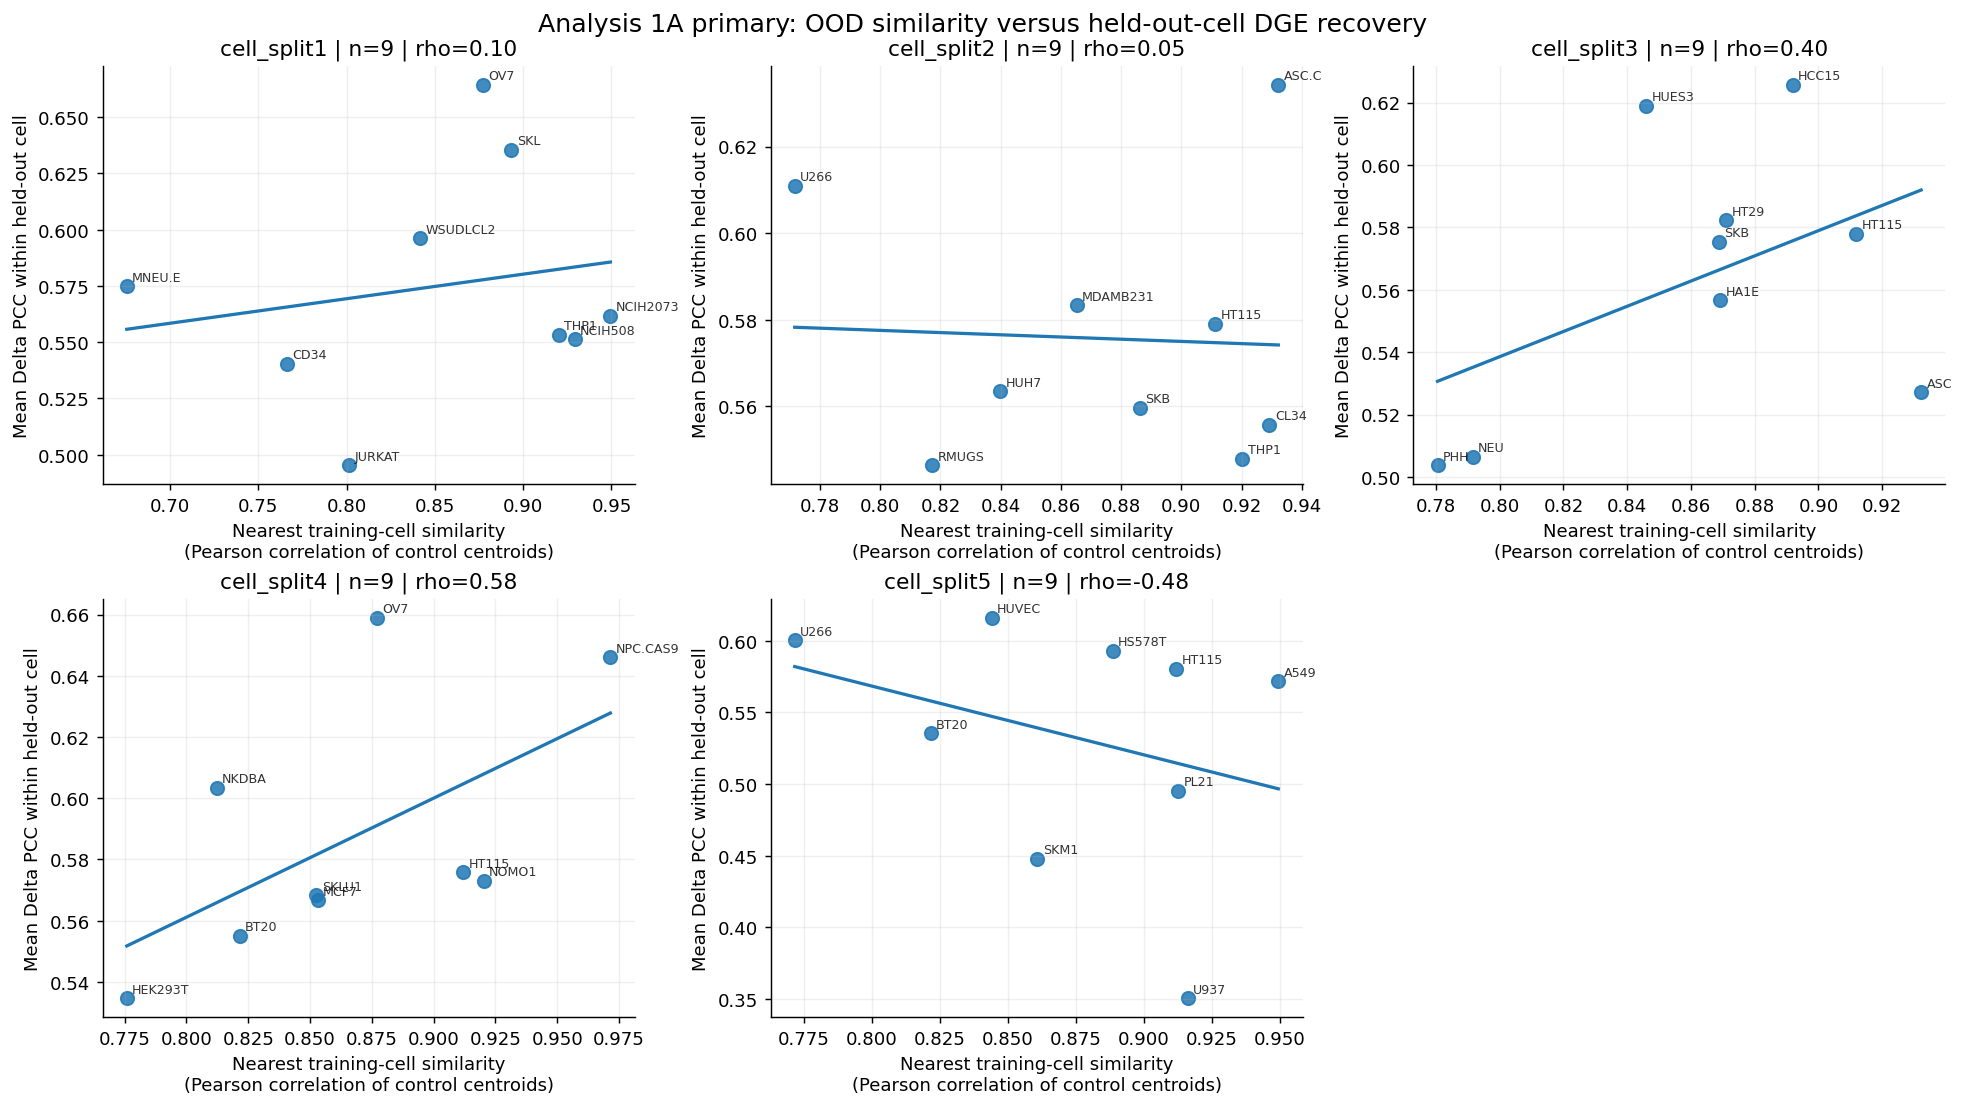

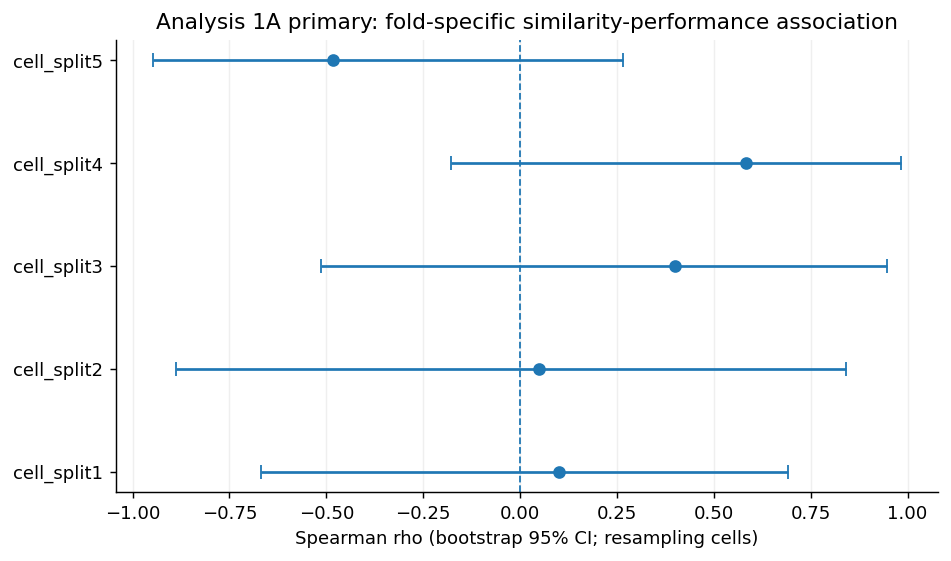

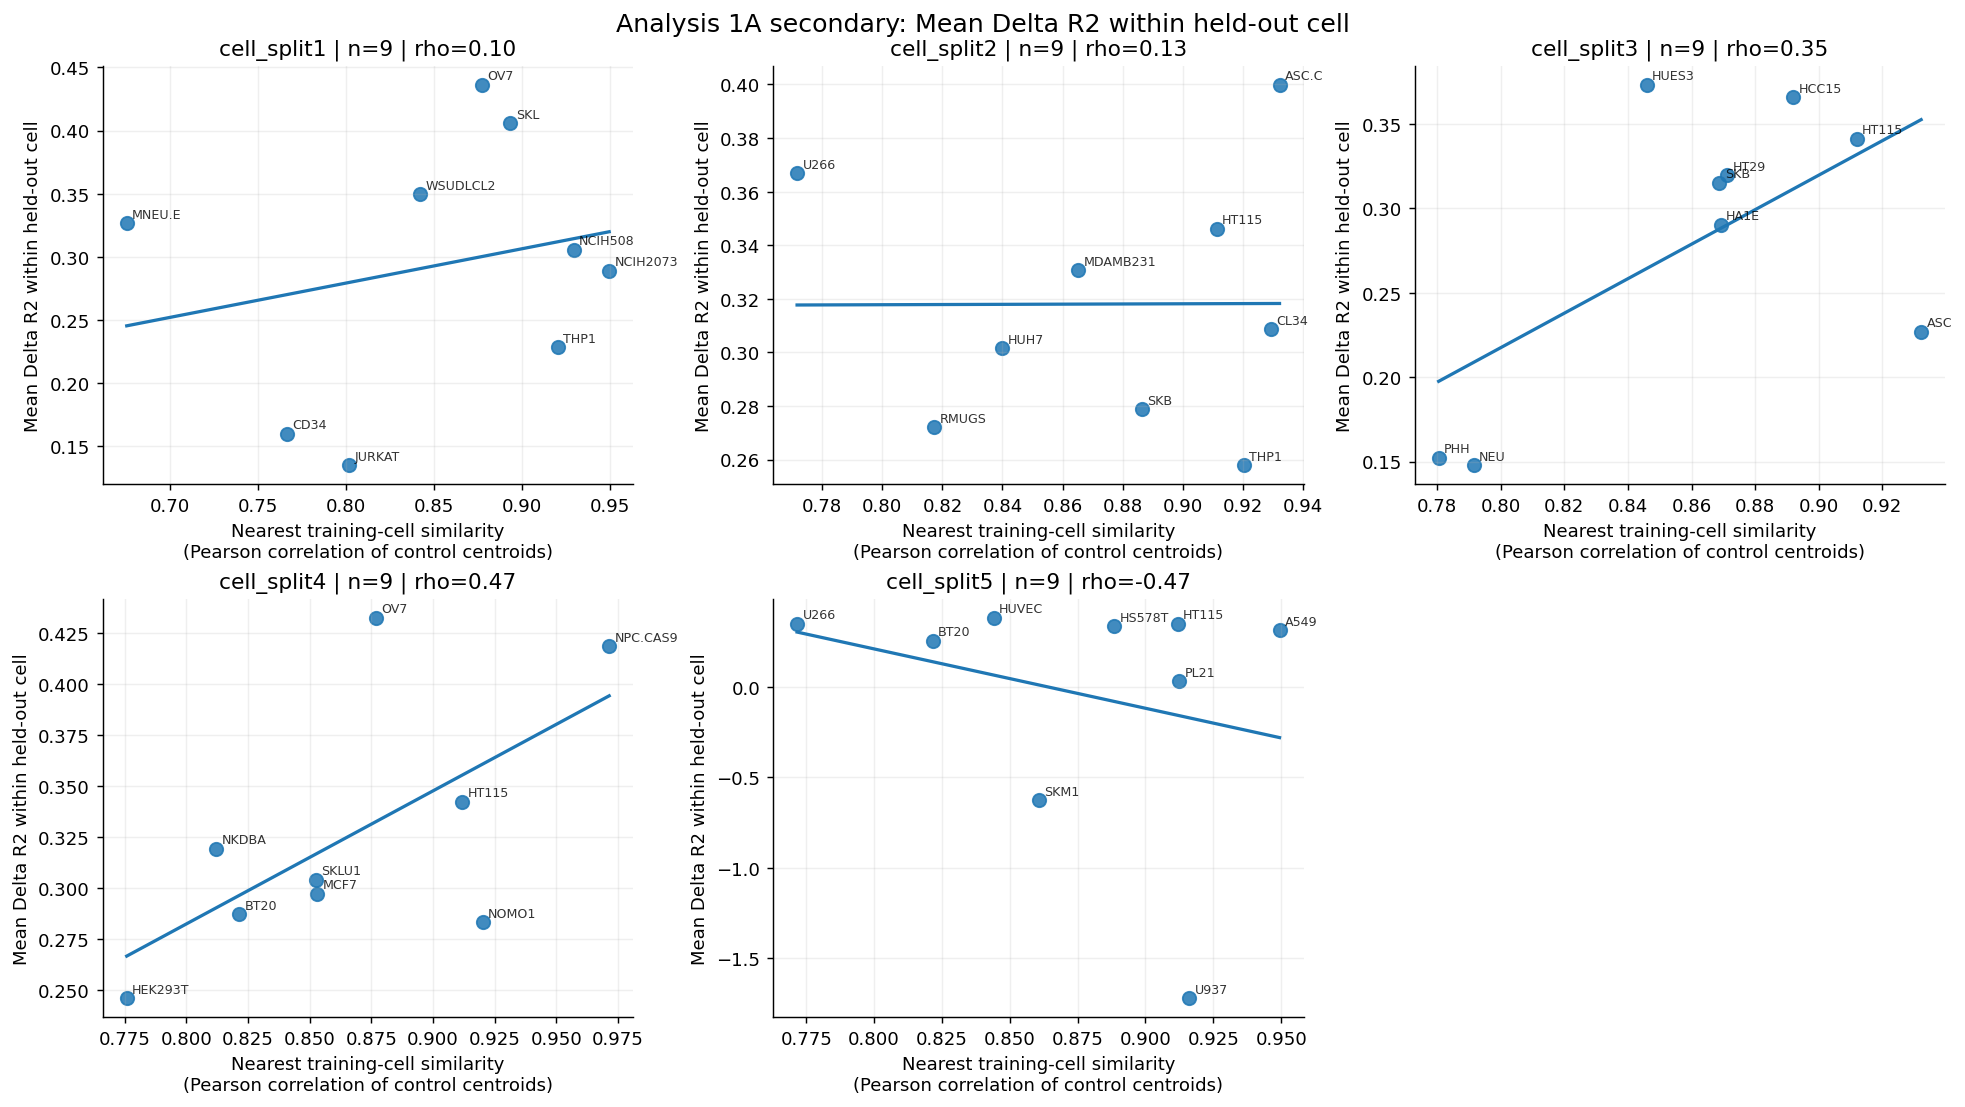

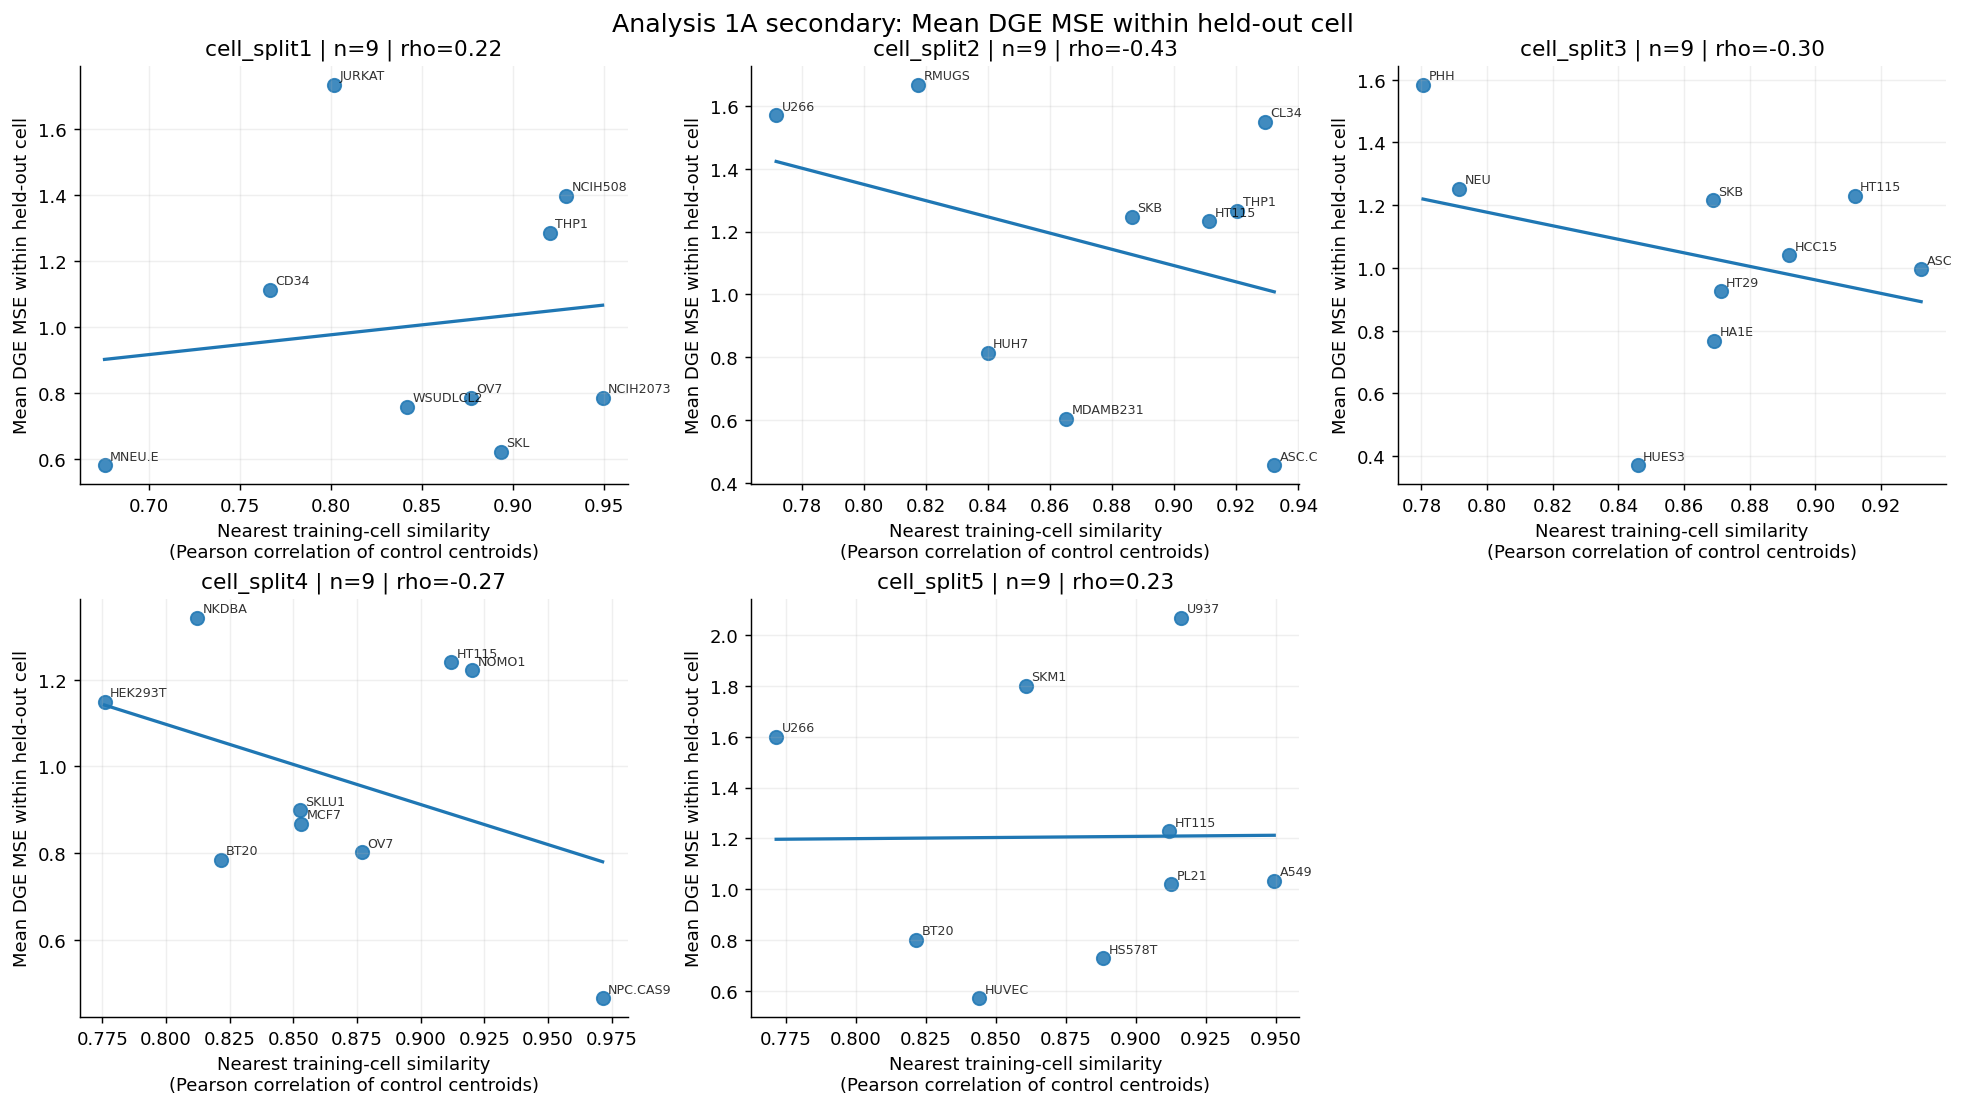

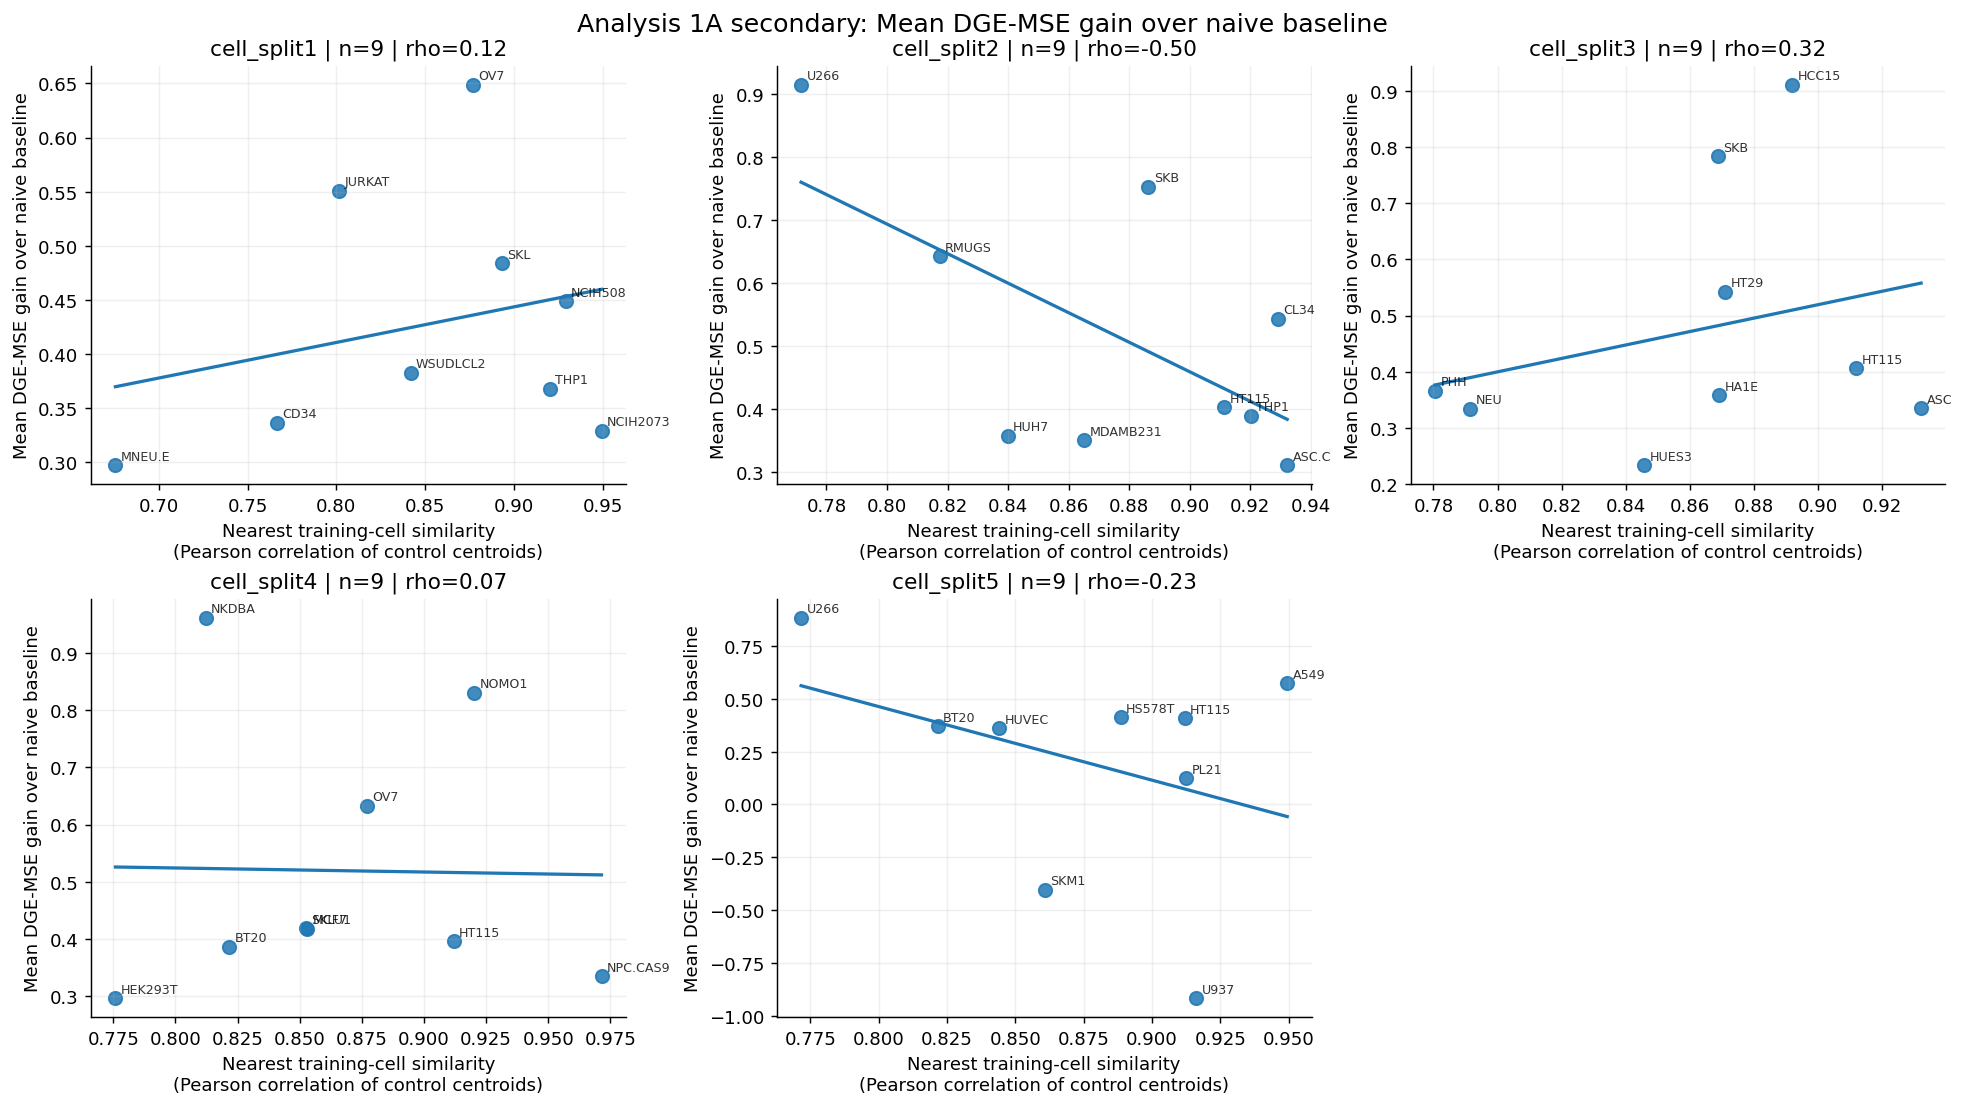

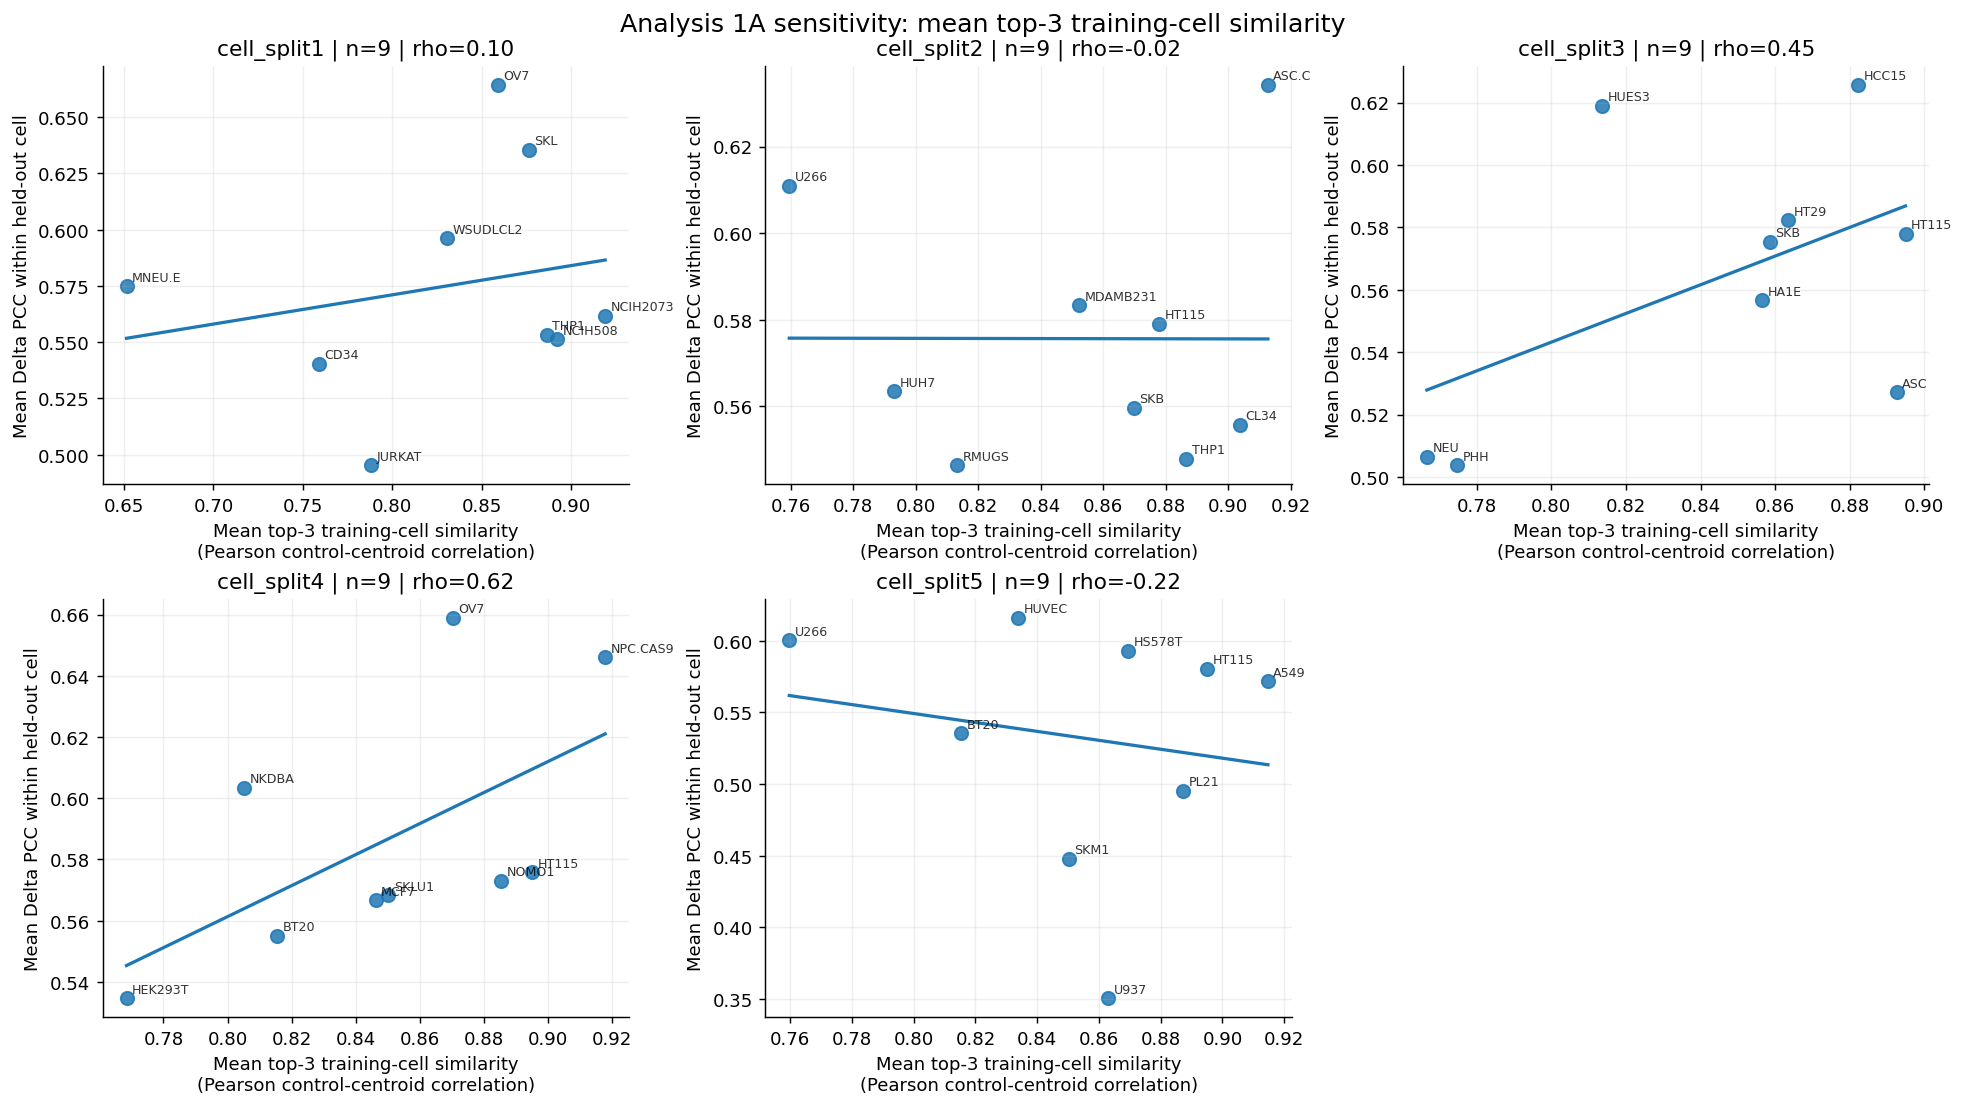

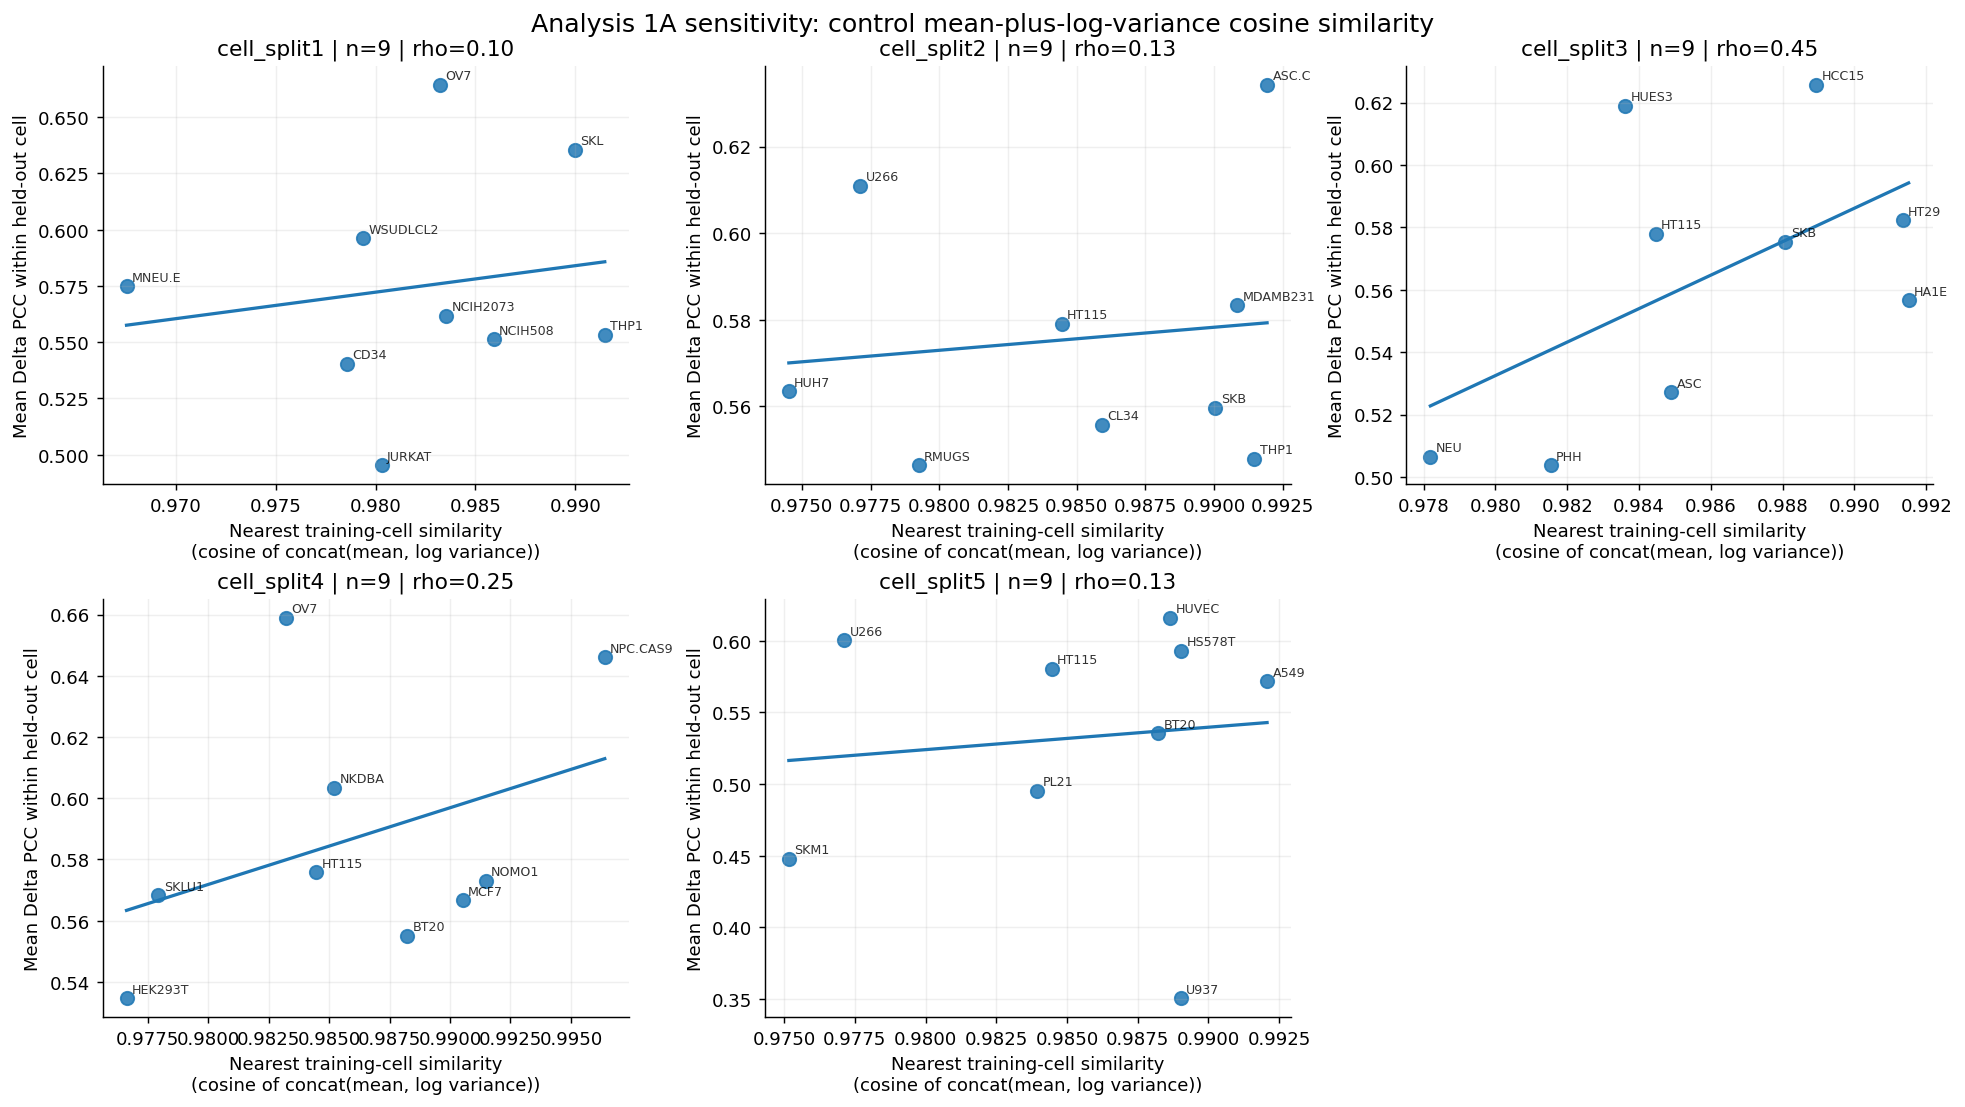

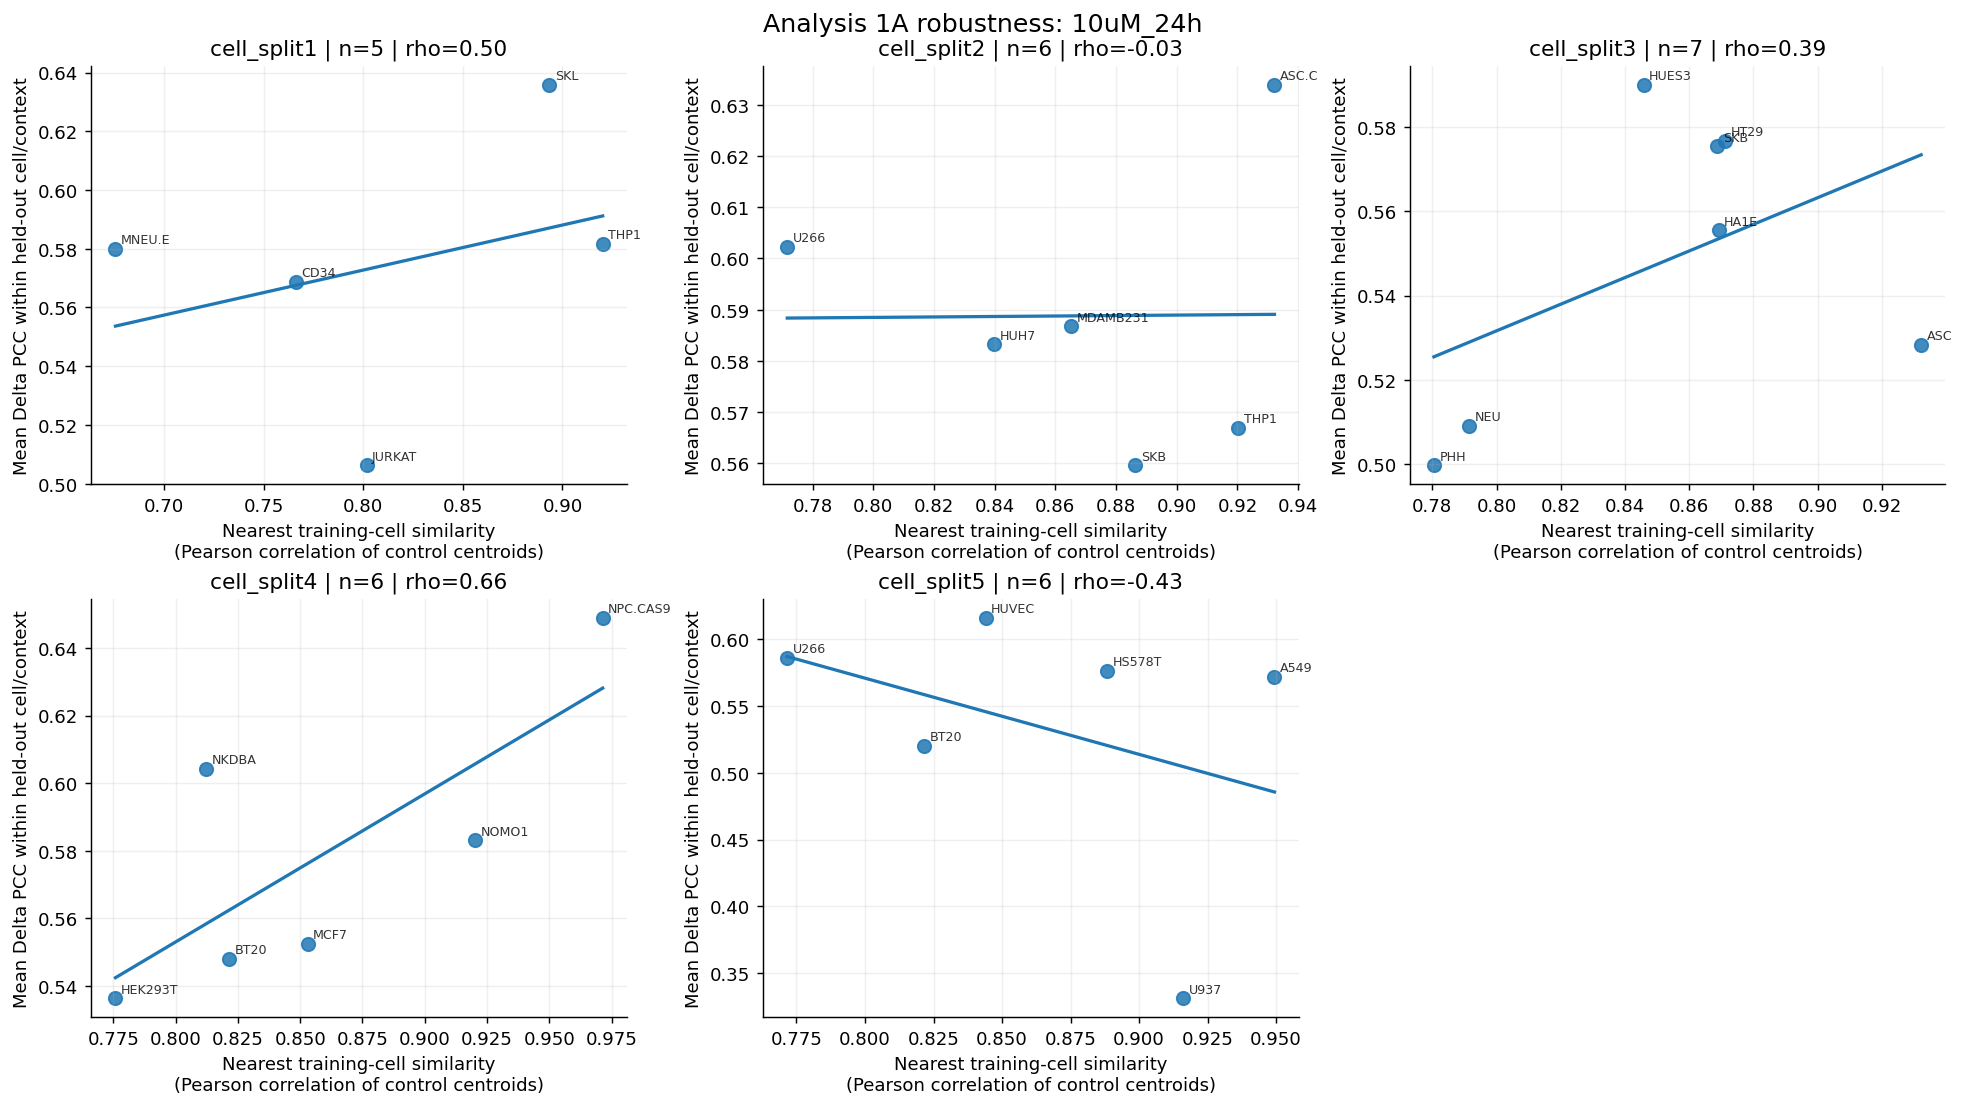

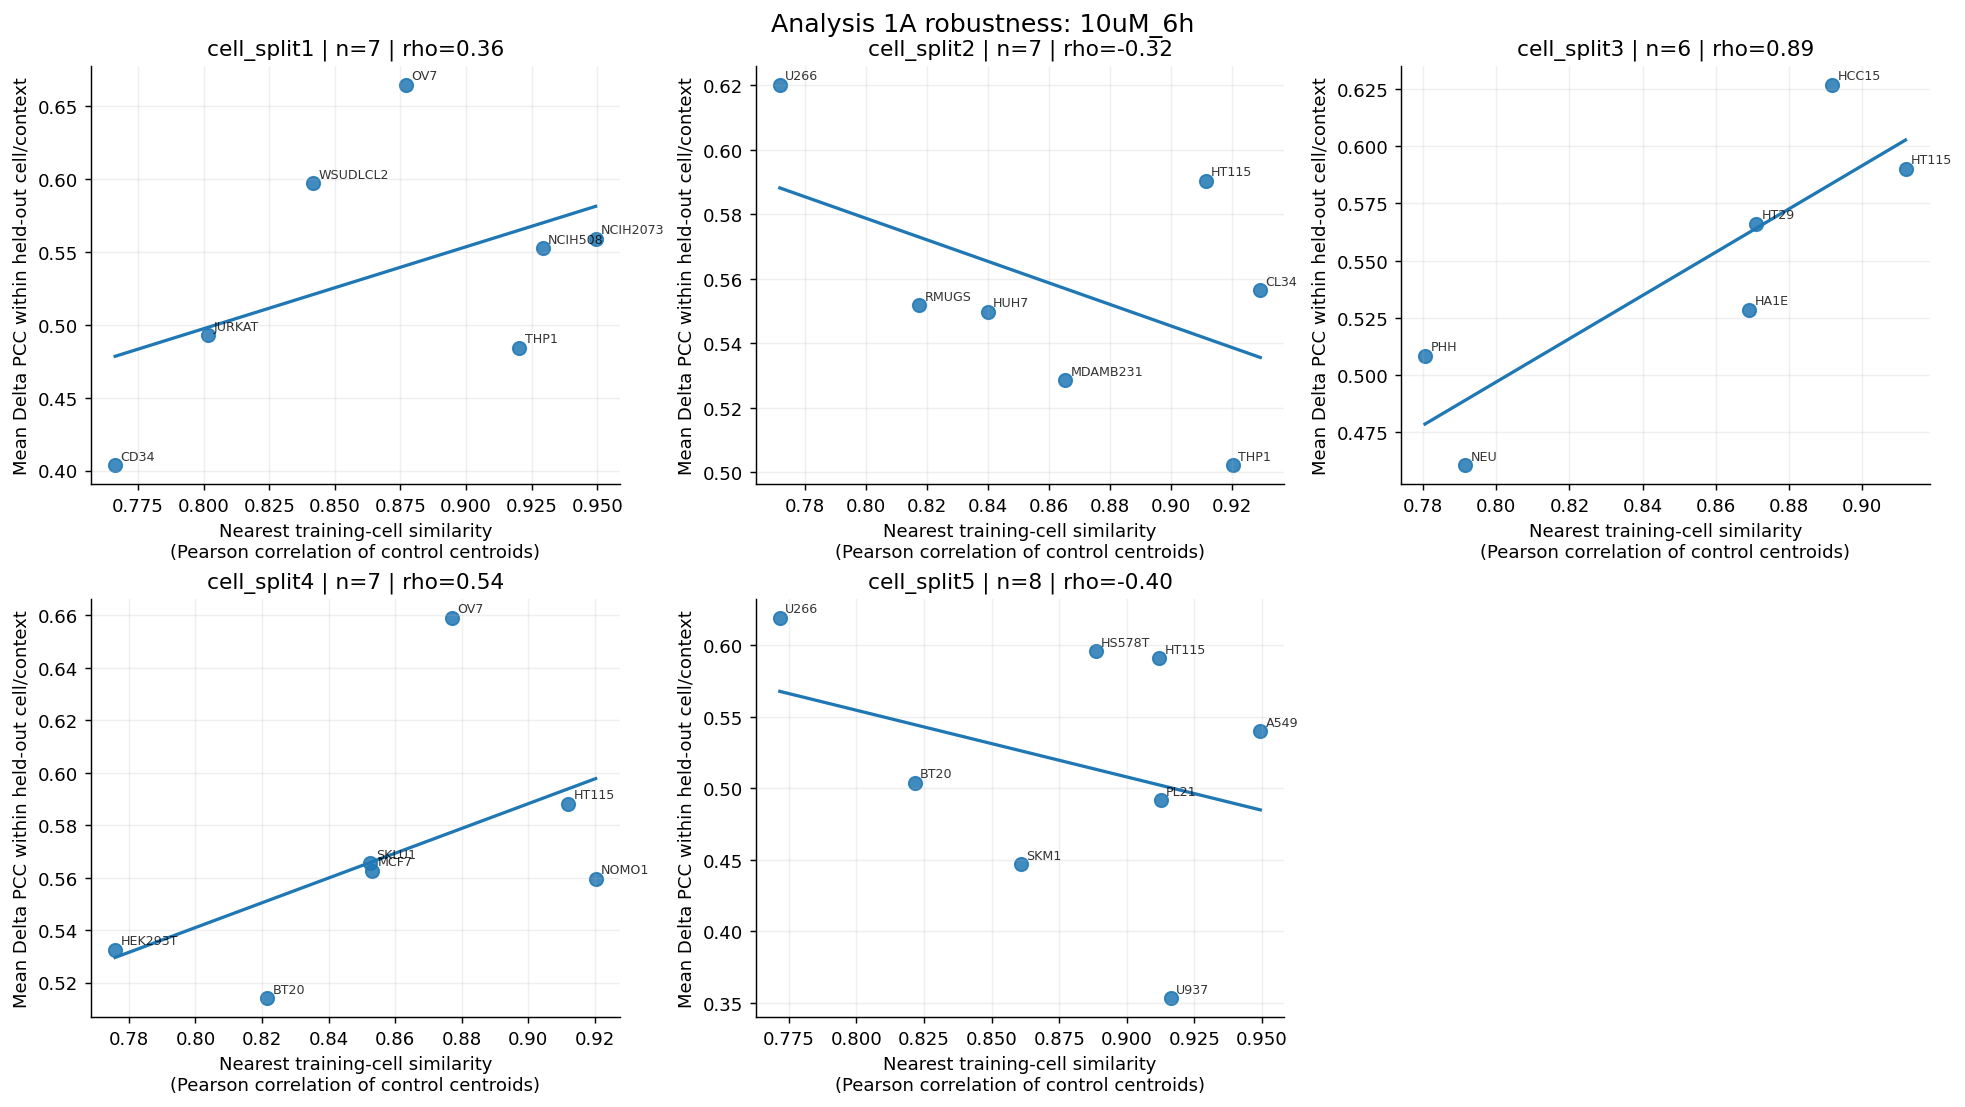

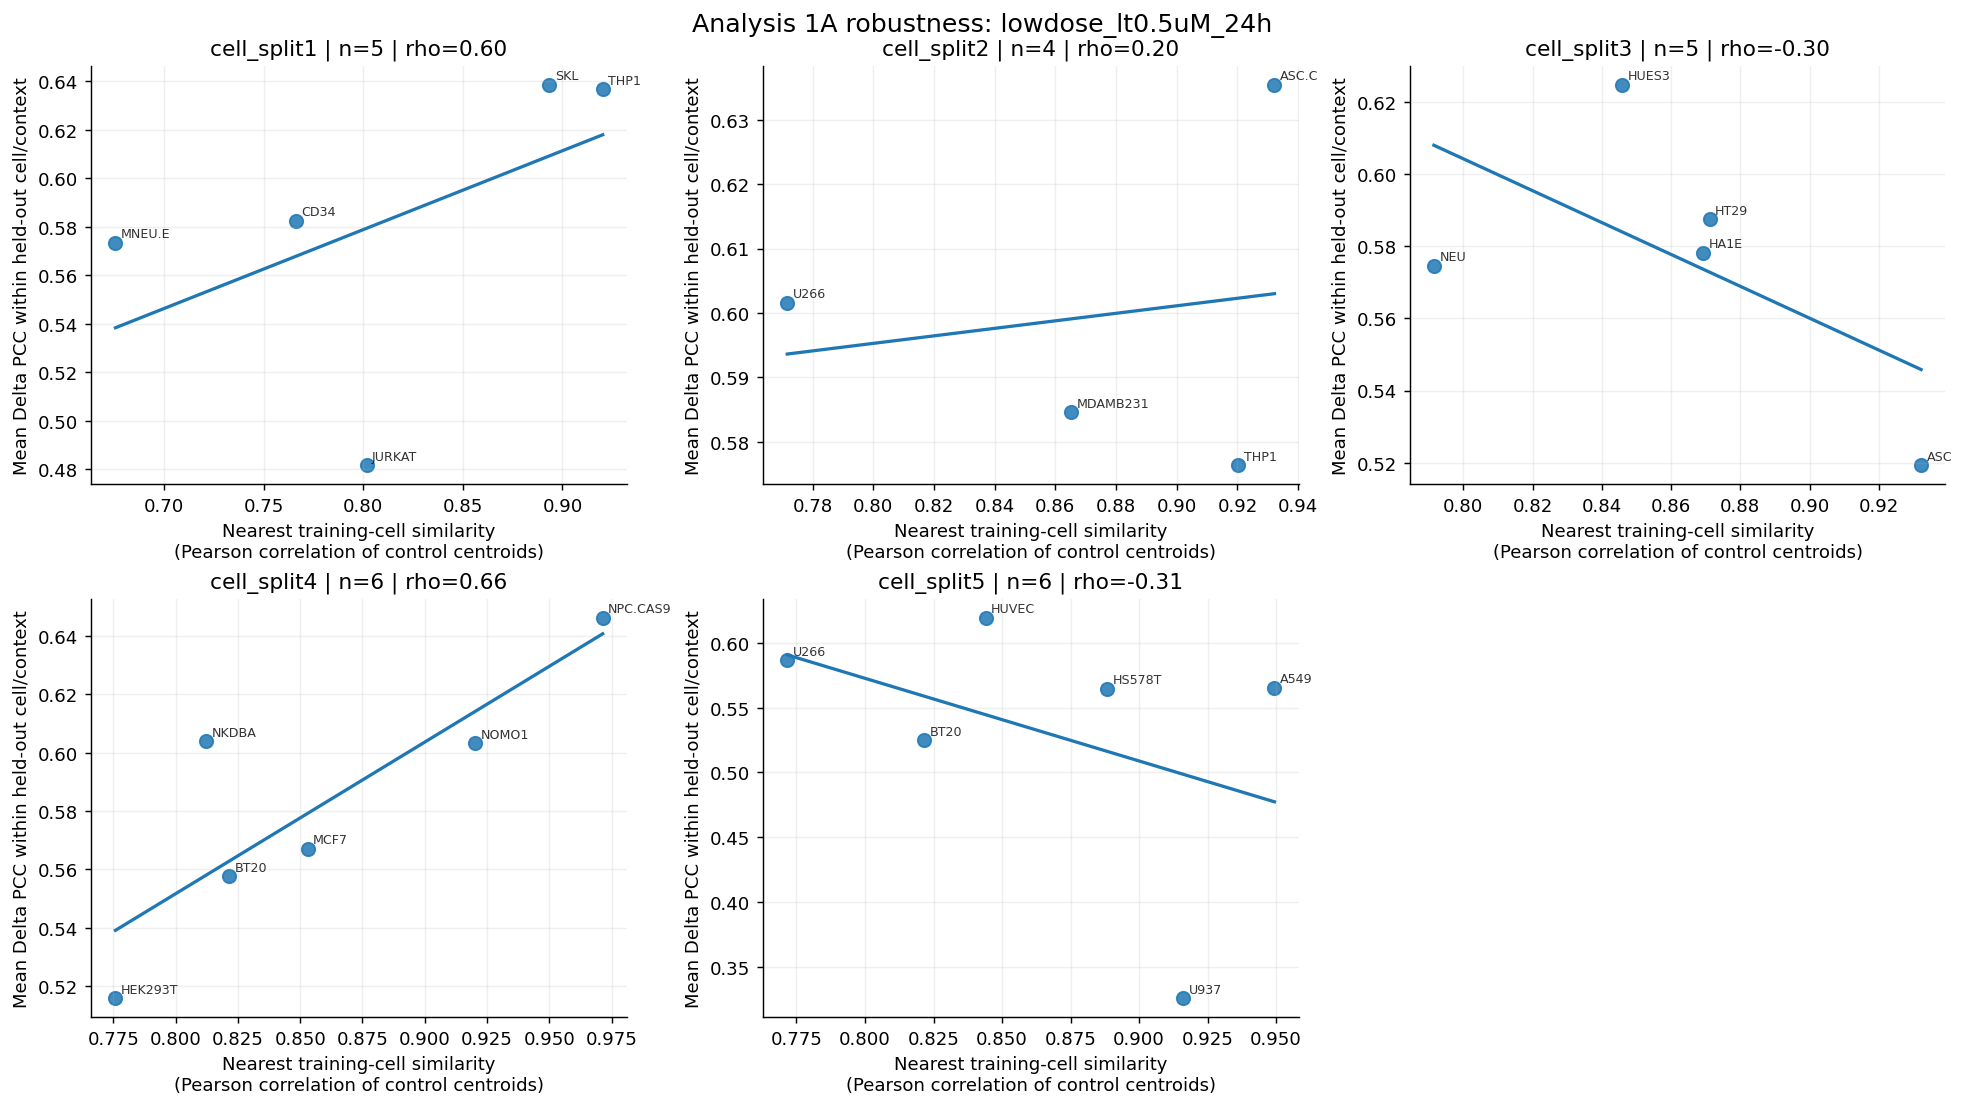

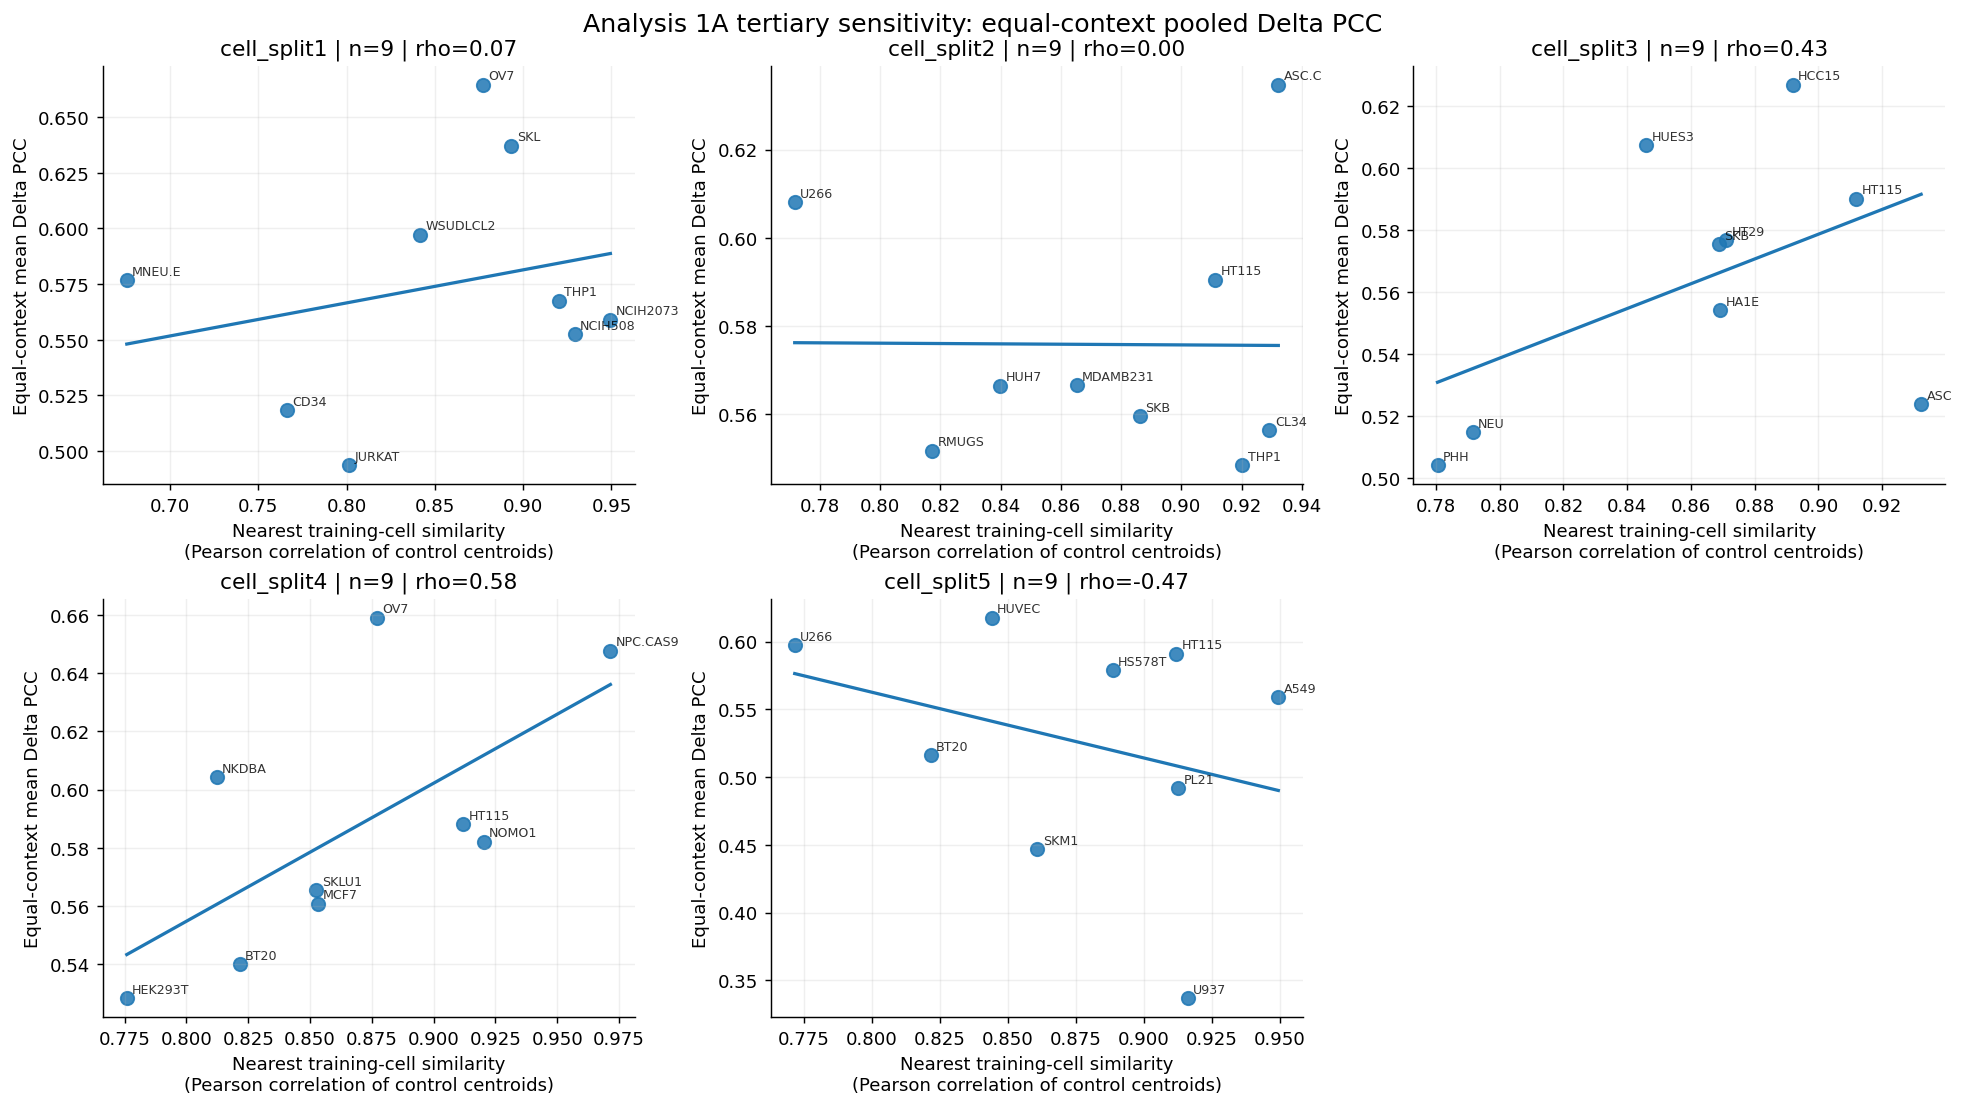

In [14]:
# Primary Analysis 1A figure
fig_primary = plot_fold_scatter(
    primary_cell_metrics,
    y_col="delta_pcc",
    y_label="Mean Delta PCC within held-out cell",
    title="Analysis 1A primary: OOD similarity versus held-out-cell DGE recovery",
    out_stem="a1_primary_similarity_vs_delta_pcc",
)

primary_delta_pcc_assoc = primary_associations.loc[primary_associations["metric"] == "delta_pcc"].copy()
fig_primary_summary = plot_association_summary(
    primary_delta_pcc_assoc,
    title="Analysis 1A primary: fold-specific similarity-performance association",
    out_stem="a1_primary_spearman_summary",
)

# Secondary metrics
for metric, ylabel, stem in [
    ("delta_r2", "Mean Delta R2 within held-out cell", "a1_secondary_similarity_vs_delta_r2"),
    ("dge_mse", "Mean DGE MSE within held-out cell", "a1_secondary_similarity_vs_dge_mse"),
    ("mse_gain_over_naive", "Mean DGE-MSE gain over naive baseline", "a1_secondary_similarity_vs_mse_gain_naive"),
]:
    plot_fold_scatter(primary_cell_metrics, metric, ylabel, f"Analysis 1A secondary: {ylabel}", stem)


# Prespecified alternative similarity descriptors (supplementary sensitivity plots).
plot_fold_scatter(
    primary_cell_metrics,
    y_col="delta_pcc",
    y_label="Mean Delta PCC within held-out cell",
    title=f"Analysis 1A sensitivity: mean top-{CONFIG['top_k_train_cells']} training-cell similarity",
    out_stem="a1_sensitivity_topk_similarity_vs_delta_pcc",
    x_col=topk_similarity_col,
    x_label=f"Mean top-{CONFIG['top_k_train_cells']} training-cell similarity\n(Pearson control-centroid correlation)",
)
plot_fold_scatter(
    primary_cell_metrics,
    y_col="delta_pcc",
    y_label="Mean Delta PCC within held-out cell",
    title="Analysis 1A sensitivity: control mean-plus-log-variance cosine similarity",
    out_stem="a1_sensitivity_mu_logvar_cosine_vs_delta_pcc",
    x_col="nearest_training_similarity_mu_logvar_cosine",
    x_label="Nearest training-cell similarity\n(cosine of concat(mean, log variance))",
)

# Fixed context robustness plots, intentionally separate by context.
for context_name, sub in context_cell_metrics.groupby("analysis_context", sort=True):
    eligible = sub.loc[sub["eligible_for_context_association"]].copy()
    if len(eligible) == 0:
        print(f"No eligible cell-context rows for {context_name}; plot skipped.")
        continue
    plot_fold_scatter(
        eligible,
        y_col="delta_pcc",
        y_label="Mean Delta PCC within held-out cell/context",
        title=f"Analysis 1A robustness: {context_name}",
        out_stem=f"a1_context_{context_name}_similarity_vs_delta_pcc",
    )

if len(equal_context) > 0:
    plot_fold_scatter(
        equal_context,
        y_col="delta_pcc_equal_context",
        y_label="Equal-context mean Delta PCC",
        title="Analysis 1A tertiary sensitivity: equal-context pooled Delta PCC",
        out_stem="a1_equal_context_similarity_vs_delta_pcc",
    )


## 11. Grand pooled descriptive plots across Monte Carlo cell-split repetitions

These figures pool all held-out cell × fold observations for visualization only. Points are colored by split, each split receives its own descriptive OLS line, and the dashed line is a pooled descriptive fit. Because individual cell lines may recur across Monte Carlo folds and each fold has a different training-cell reference set, the pooled Spearman rho and pooled OLS line are **not** used for primary inferential claims. Fold-specific results remain primary.


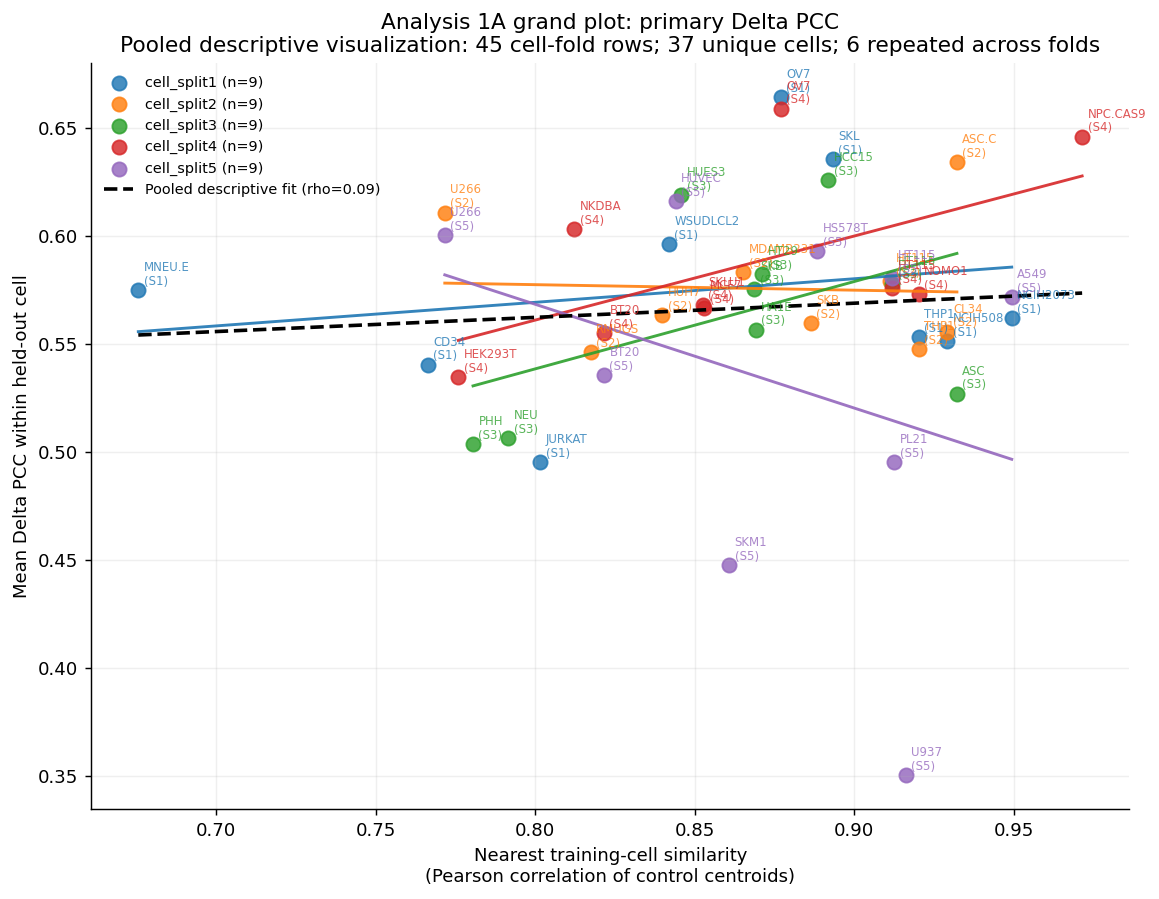

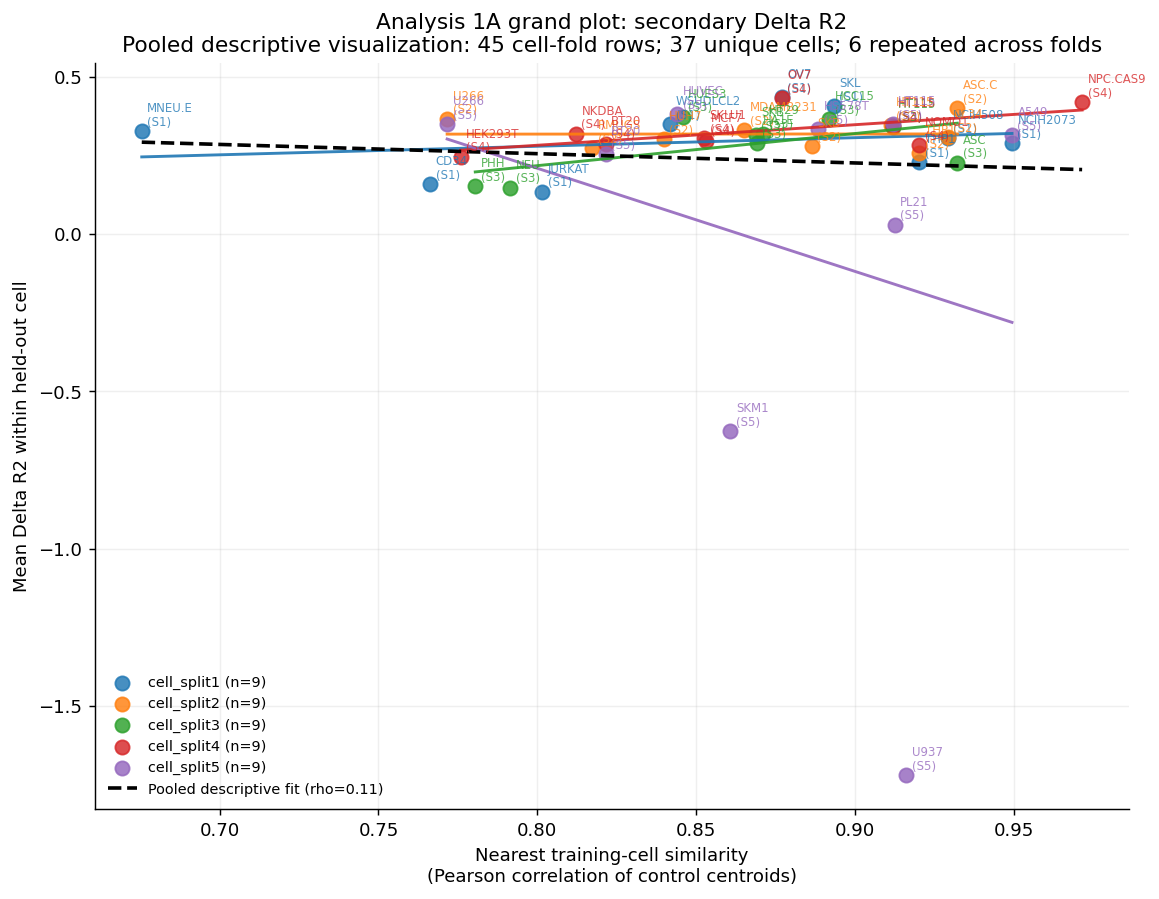

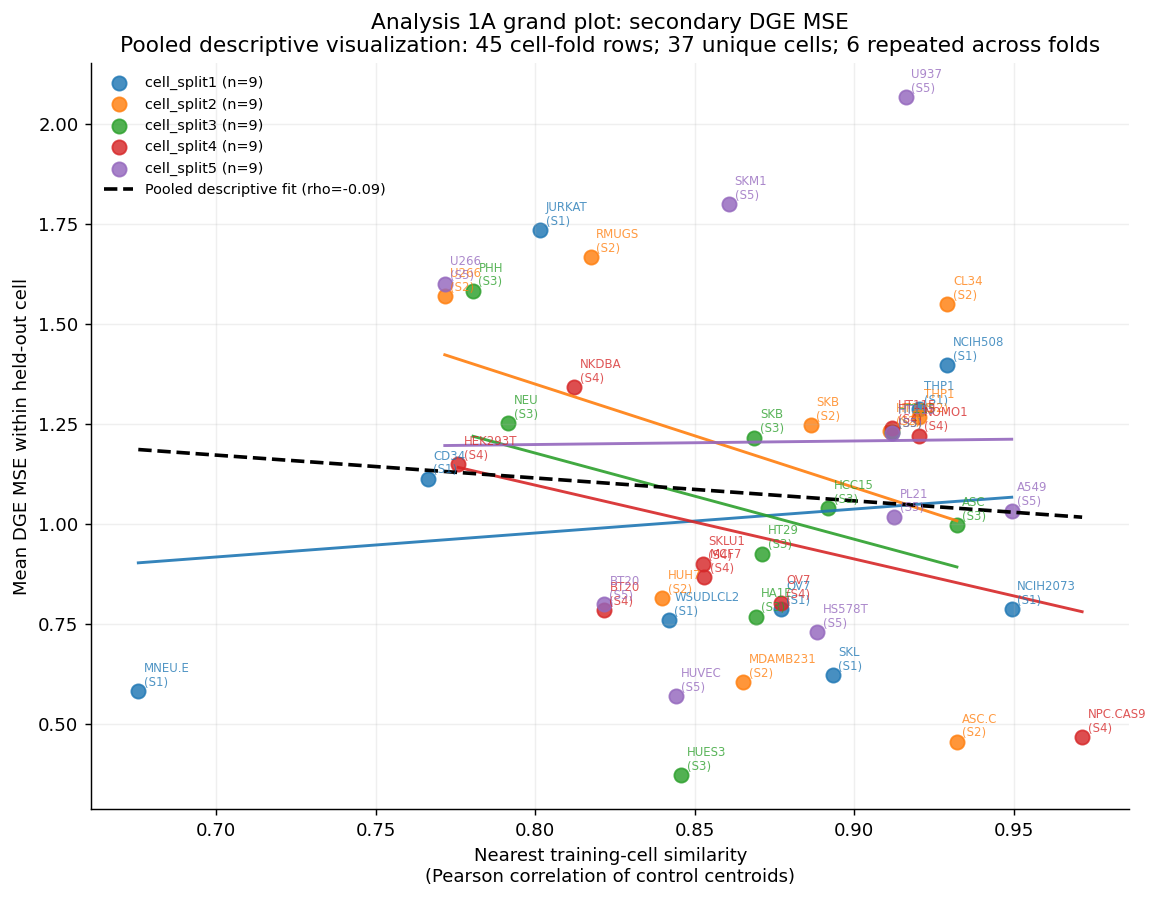

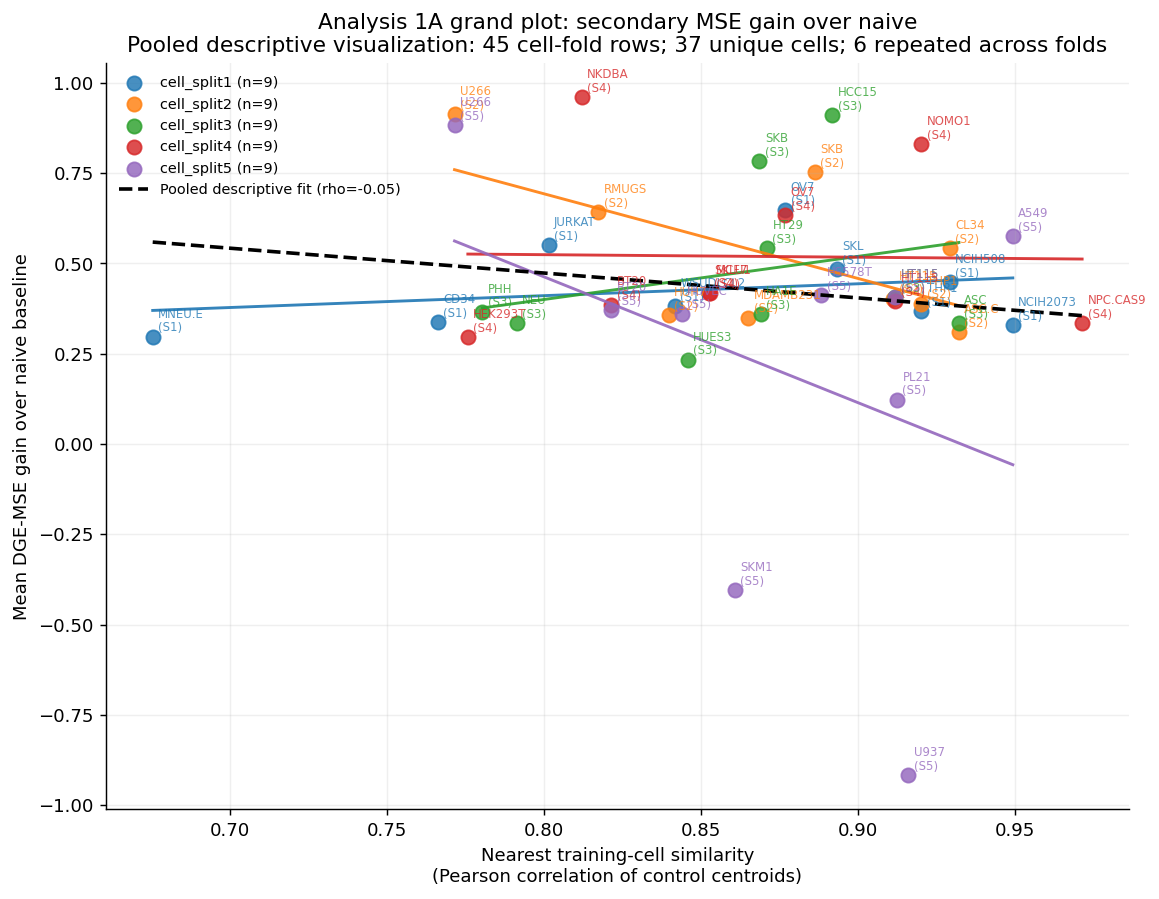

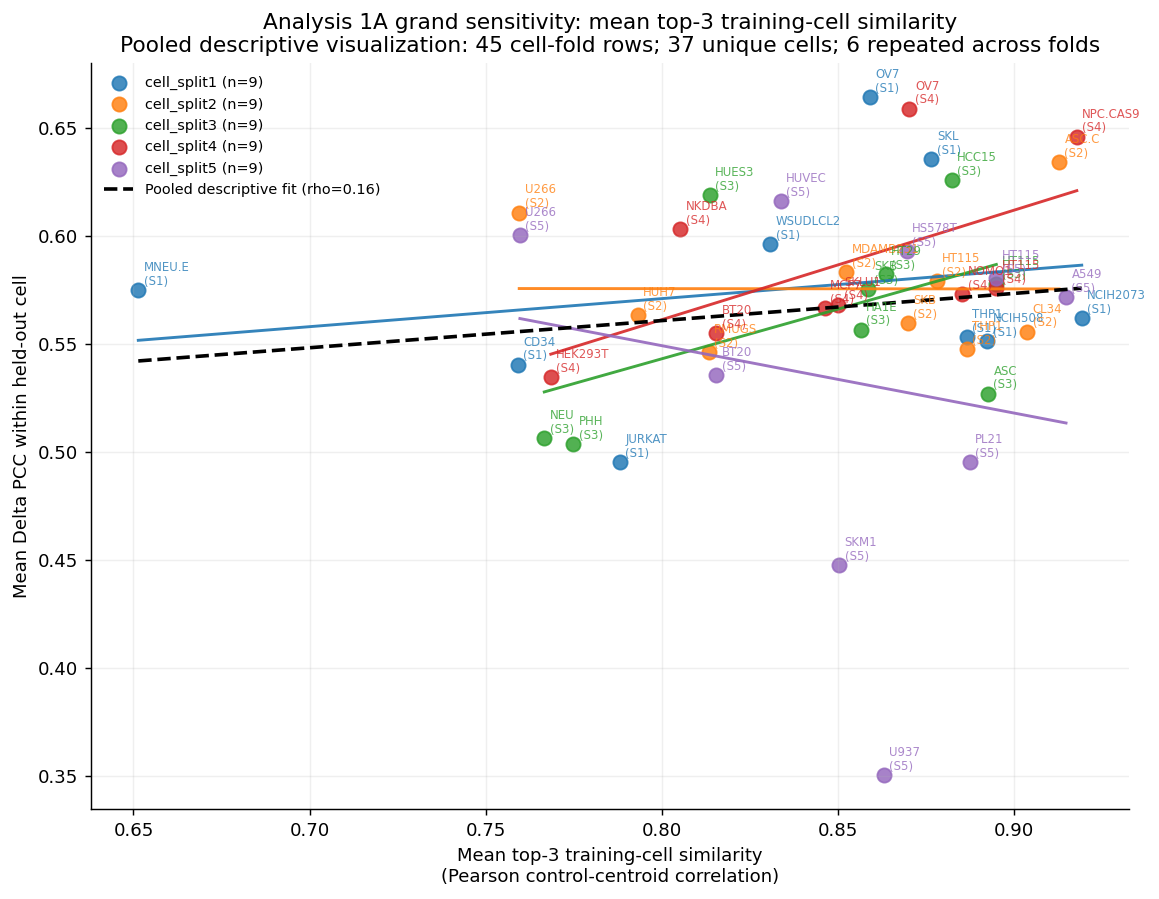

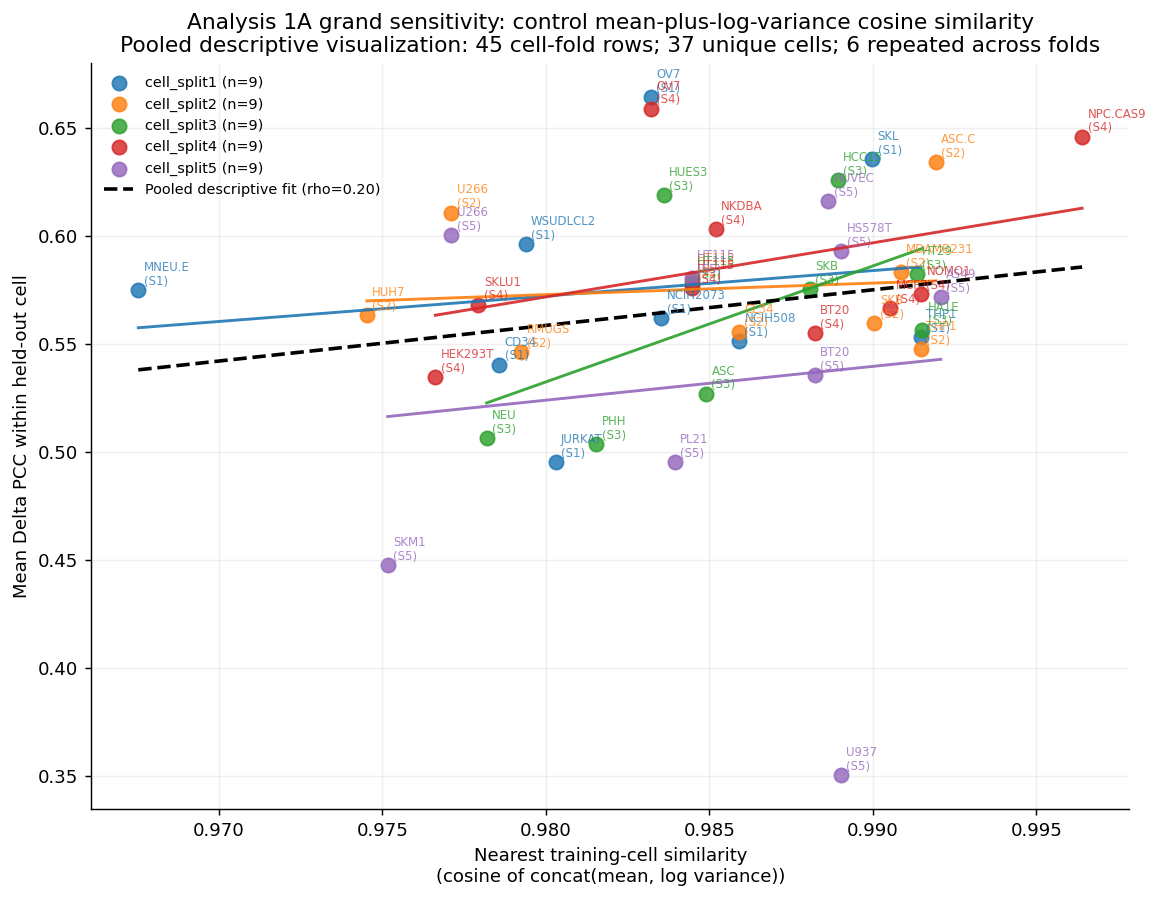

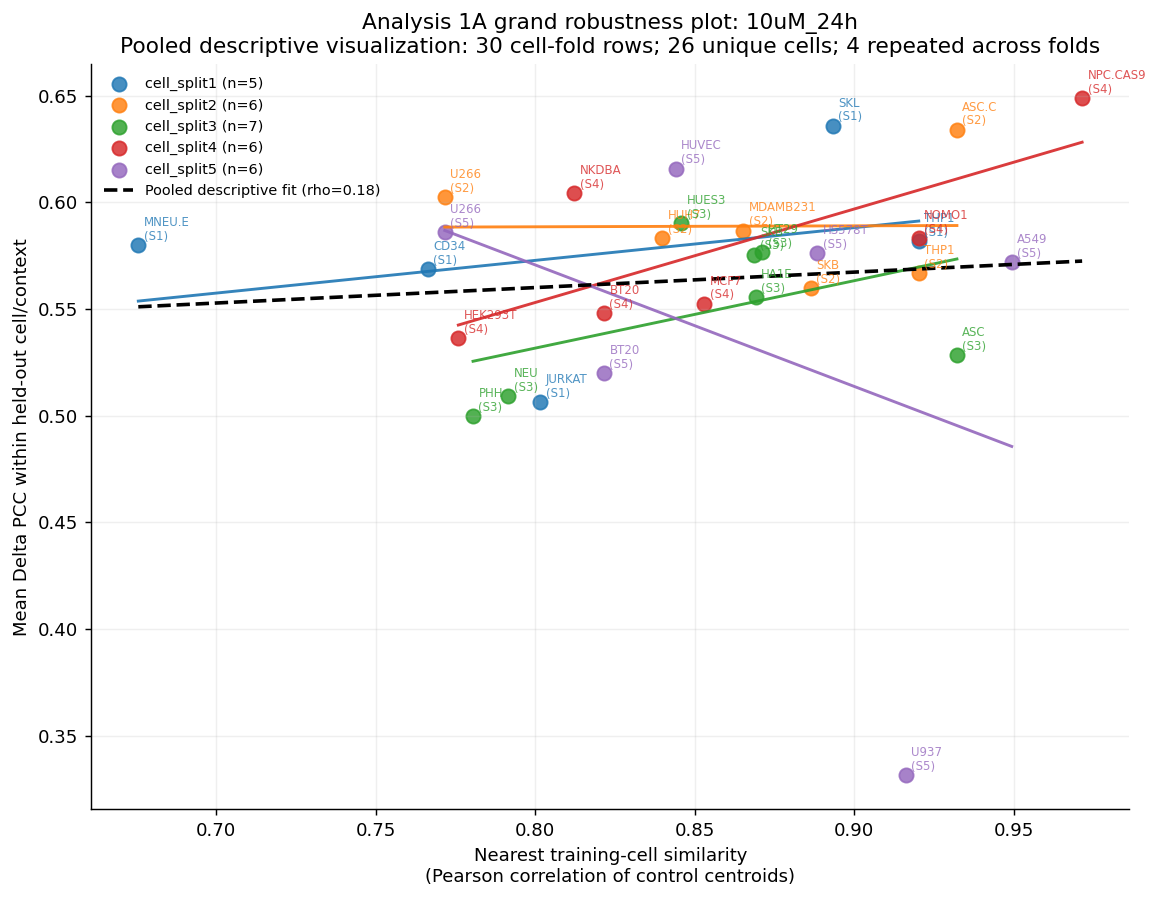

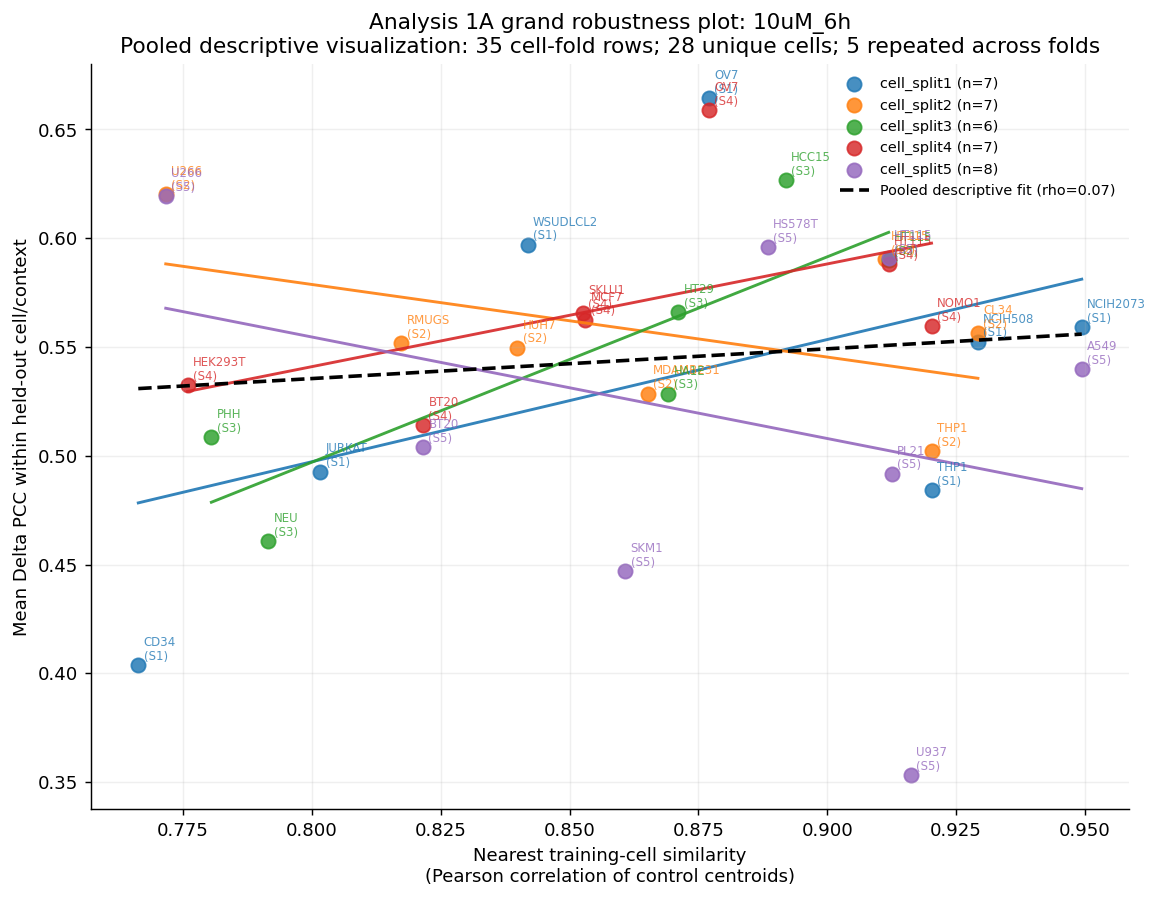

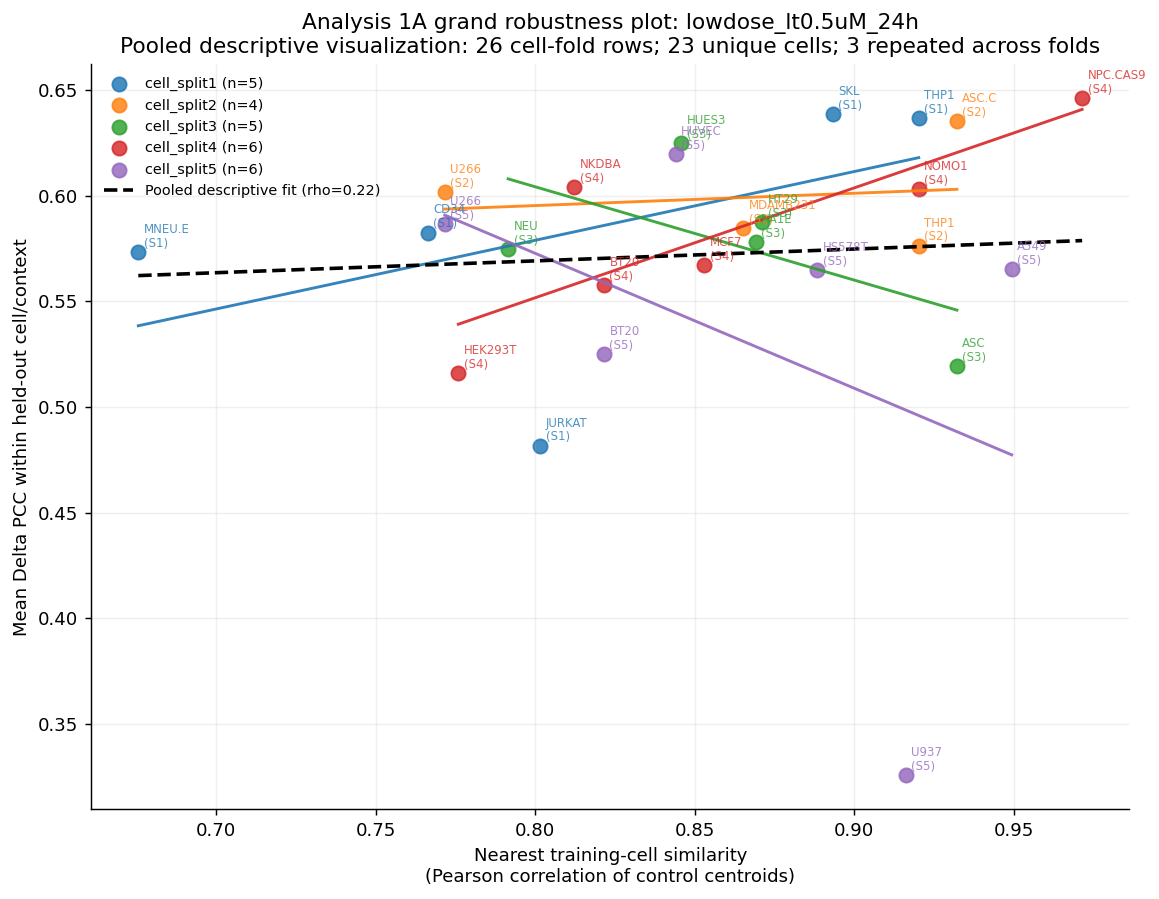

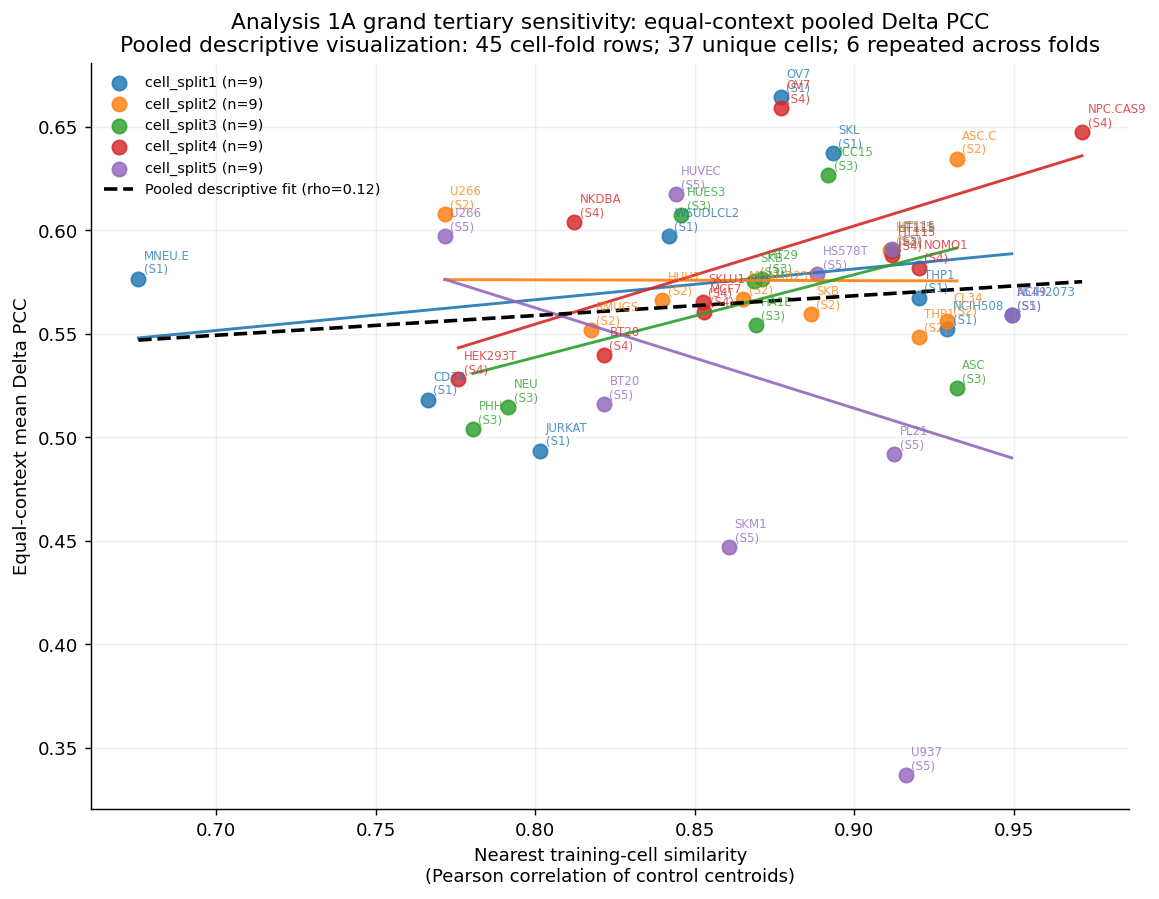

Grand pooled descriptive plot summary table


,plot_name,n_cell_fold_rows,n_unique_cells,n_folds,n_repeated_cells,pooled_spearman_rho_descriptive,pooled_spearman_p_descriptive,pooled_ols_slope_descriptive,pooled_ols_intercept_descriptive,pooled_ols_r2_descriptive
0,a1_grand_primary_similarity_vs_delta_pcc,45,37,5,6,0.0913,0.5507,0.0656,0.5099,0.0054
1,a1_grand_secondary_similarity_vs_delta_r2,45,37,5,6,0.1144,0.4542,-0.2944,0.4910,0.0029
2,a1_grand_secondary_similarity_vs_dge_mse,45,37,5,6,-0.0912,0.5512,-0.5721,1.5726,0.0080
3,a1_grand_secondary_similarity_vs_mse_gain_naive,45,37,5,6,-0.0492,0.7484,-0.6881,1.0238,0.0183
4,a1_grand_sensitivity_topk_similarity_vs_delta_pcc,45,37,5,6,0.1588,0.2975,0.1258,0.4603,0.0161
5,a1_grand_sensitivity_mu_logvar_cosine_vs_delta...,45,37,5,6,0.1955,0.1981,1.6494,-1.0577,0.0324
6,a1_grand_context_10uM_24h_similarity_vs_delta_pcc,30,26,5,4,0.1797,0.3421,0.0724,0.5021,0.0073
7,a1_grand_context_10uM_6h_similarity_vs_delta_pcc,35,28,5,5,0.0709,0.6855,0.1367,0.4261,0.0132
8,a1_grand_context_lowdose_lt0.5uM_24h_similarit...,26,23,5,3,0.2194,0.2815,0.0560,0.5243,0.0038
9,a1_grand_equal_context_similarity_vs_delta_pcc,45,37,5,6,0.1230,0.4207,0.0953,0.4826,0.0105


In [15]:
# -----------------------------------------------------------------------------
# Grand pooled descriptive plots.
# These plots visualize all held-out cell × fold observations together while
# preserving fold identity. They are descriptive only: repeated cell lines across
# Monte Carlo folds and fold-specific training references preclude treating all
# plotted rows as independent observations for primary inference.
# -----------------------------------------------------------------------------
def descriptive_pooled_summary(cell_df: pd.DataFrame, x_col: str, y_col: str, plot_name: str) -> dict:
    sub = cell_df[["split_type", "cell_id", x_col, y_col]].copy()
    valid = np.isfinite(sub[x_col].to_numpy(float)) & np.isfinite(sub[y_col].to_numpy(float))
    sub = sub.loc[valid].copy()
    rho, p = safe_spearman(sub[x_col], sub[y_col])
    slope, intercept, r2 = ols_slope_intercept(sub[x_col], sub[y_col])
    return {
        "plot_name": plot_name,
        "n_cell_fold_rows": int(len(sub)),
        "n_unique_cells": int(sub["cell_id"].nunique()),
        "n_folds": int(sub["split_type"].nunique()),
        "n_repeated_cells": int((sub.groupby("cell_id")["split_type"].nunique() > 1).sum()),
        "pooled_spearman_rho_descriptive": rho,
        "pooled_spearman_p_descriptive": p,
        "pooled_ols_slope_descriptive": slope,
        "pooled_ols_intercept_descriptive": intercept,
        "pooled_ols_r2_descriptive": r2,
    }


def plot_grand_scatter(
    cell_df: pd.DataFrame,
    y_col: str,
    y_label: str,
    title: str,
    out_stem: str,
    x_col: str = "nearest_training_similarity_pearson",
    x_label: str = "Nearest training-cell similarity\n(Pearson correlation of control centroids)",
    annotate_cells: bool = True,
):
    required = ["split_type", "cell_id", x_col, y_col]
    missing = [c for c in required if c not in cell_df.columns]
    require(not missing, f"Grand plot missing columns: {missing}")

    plot_df = cell_df[required].copy()
    valid = np.isfinite(plot_df[x_col].to_numpy(float)) & np.isfinite(plot_df[y_col].to_numpy(float))
    plot_df = plot_df.loc[valid].copy()
    require(len(plot_df) > 0, f"No finite data available for grand plot: {out_stem}")

    folds = sorted(plot_df["split_type"].unique())
    fig, ax = plt.subplots(figsize=(8.8, 6.8), constrained_layout=True)

    # Let matplotlib assign the default categorical colors consistently.
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fold_color = {fold: color_cycle[i % len(color_cycle)] for i, fold in enumerate(folds)}

    for fold in folds:
        sub = plot_df.loc[plot_df["split_type"] == fold].copy()
        color = fold_color[fold]
        ax.scatter(sub[x_col], sub[y_col], s=62, alpha=0.82, label=f"{fold} (n={len(sub)})", color=color)
        if annotate_cells:
            for _, r in sub.iterrows():
                ax.annotate(
                    f"{r['cell_id']}\n({fold.replace('cell_split', 'S')})",
                    (r[x_col], r[y_col]),
                    xytext=(3, 3),
                    textcoords="offset points",
                    fontsize=6.5,
                    alpha=0.78,
                    color=color,
                )
        slope, intercept, _ = ols_slope_intercept(sub[x_col], sub[y_col])
        if np.isfinite(slope):
            xs = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
            ax.plot(xs, intercept + slope * xs, linewidth=1.6, alpha=0.9, color=color)

    pooled_slope, pooled_intercept, _ = ols_slope_intercept(plot_df[x_col], plot_df[y_col])
    pooled_rho, _ = safe_spearman(plot_df[x_col], plot_df[y_col])
    if np.isfinite(pooled_slope):
        xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 150)
        ax.plot(
            xs,
            pooled_intercept + pooled_slope * xs,
            linestyle="--",
            linewidth=2.0,
            color="black",
            label=f"Pooled descriptive fit (rho={pooled_rho:.2f})",
        )

    n_unique = plot_df["cell_id"].nunique()
    n_repeated = (plot_df.groupby("cell_id")["split_type"].nunique() > 1).sum()
    ax.set_title(
        f"{title}\nPooled descriptive visualization: {len(plot_df)} cell-fold rows; "
        f"{n_unique} unique cells; {n_repeated} repeated across folds",
        fontsize=12,
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8, loc="best")

    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{out_stem}.{ext}", bbox_inches="tight")
    plt.show()
    return fig, descriptive_pooled_summary(plot_df, x_col=x_col, y_col=y_col, plot_name=out_stem)


grand_plot_summaries = []

# Primary and secondary observed-mixture outcomes.
for metric, ylabel, stem, title in [
    ("delta_pcc", "Mean Delta PCC within held-out cell", "a1_grand_primary_similarity_vs_delta_pcc", "Analysis 1A grand plot: primary Delta PCC"),
    ("delta_r2", "Mean Delta R2 within held-out cell", "a1_grand_secondary_similarity_vs_delta_r2", "Analysis 1A grand plot: secondary Delta R2"),
    ("dge_mse", "Mean DGE MSE within held-out cell", "a1_grand_secondary_similarity_vs_dge_mse", "Analysis 1A grand plot: secondary DGE MSE"),
    ("mse_gain_over_naive", "Mean DGE-MSE gain over naive baseline", "a1_grand_secondary_similarity_vs_mse_gain_naive", "Analysis 1A grand plot: secondary MSE gain over naive"),
]:
    _, summary = plot_grand_scatter(primary_cell_metrics, metric, ylabel, title, stem)
    grand_plot_summaries.append(summary)

# Prespecified alternative similarity descriptors.
_, summary = plot_grand_scatter(
    primary_cell_metrics,
    y_col="delta_pcc",
    y_label="Mean Delta PCC within held-out cell",
    title=f"Analysis 1A grand sensitivity: mean top-{CONFIG['top_k_train_cells']} training-cell similarity",
    out_stem="a1_grand_sensitivity_topk_similarity_vs_delta_pcc",
    x_col=topk_similarity_col,
    x_label=f"Mean top-{CONFIG['top_k_train_cells']} training-cell similarity\n(Pearson control-centroid correlation)",
)
grand_plot_summaries.append(summary)

_, summary = plot_grand_scatter(
    primary_cell_metrics,
    y_col="delta_pcc",
    y_label="Mean Delta PCC within held-out cell",
    title="Analysis 1A grand sensitivity: control mean-plus-log-variance cosine similarity",
    out_stem="a1_grand_sensitivity_mu_logvar_cosine_vs_delta_pcc",
    x_col="nearest_training_similarity_mu_logvar_cosine",
    x_label="Nearest training-cell similarity\n(cosine of concat(mean, log variance))",
)
grand_plot_summaries.append(summary)

# Fixed-context robustness grand plots: context-specific rows remain separate.
for context_name, sub in context_cell_metrics.groupby("analysis_context", sort=True):
    eligible = sub.loc[sub["eligible_for_context_association"]].copy()
    if len(eligible) == 0:
        print(f"No eligible cell-context rows for grand plot: {context_name}; skipped.")
        continue
    _, summary = plot_grand_scatter(
        eligible,
        y_col="delta_pcc",
        y_label="Mean Delta PCC within held-out cell/context",
        title=f"Analysis 1A grand robustness plot: {context_name}",
        out_stem=f"a1_grand_context_{context_name}_similarity_vs_delta_pcc",
    )
    grand_plot_summaries.append(summary)

# Equal-context tertiary sensitivity grand plot.
if len(equal_context) > 0:
    _, summary = plot_grand_scatter(
        equal_context,
        y_col="delta_pcc_equal_context",
        y_label="Equal-context mean Delta PCC",
        title="Analysis 1A grand tertiary sensitivity: equal-context pooled Delta PCC",
        out_stem="a1_grand_equal_context_similarity_vs_delta_pcc",
    )
    grand_plot_summaries.append(summary)

grand_plot_summary_table = pd.DataFrame(grand_plot_summaries)
save_table(grand_plot_summary_table, "a1_grand_plot_descriptive_summaries")
print("Grand pooled descriptive plot summary table")
display(grand_plot_summary_table.round(4))


## 12. Produce compact reporting tables and a manifest

The reporting table gives fold-specific primary results and the across-fold mean +/- SD. Interpret the association direction descriptively because each fold has only a small number of held-out cells.

In [16]:
primary_report = primary_delta_pcc_assoc[[
    "split_type", "n_cells", "spearman_rho", "spearman_p_descriptive",
    "spearman_bootstrap_ci_low", "spearman_bootstrap_ci_high",
    "ols_slope", "ols_slope_bootstrap_ci_low", "ols_slope_bootstrap_ci_high", "ols_r2"
]].copy()
primary_report["mean_delta_pcc"] = primary_report["split_type"].map(primary_cell_metrics.groupby("split_type")["delta_pcc"].mean())
primary_report["mean_nearest_similarity"] = primary_report["split_type"].map(primary_cell_metrics.groupby("split_type")["nearest_training_similarity_pearson"].mean())
primary_report["n_test_perturbations"] = primary_report["split_type"].map(primary_cell_metrics.groupby("split_type")["n_test_perturbations"].sum())
save_table(primary_report, "a1_primary_reporting_table")

across_fold_primary = pd.DataFrame([{
    "n_folds": int(primary_report["split_type"].nunique()),
    "mean_fold_spearman_rho": primary_report["spearman_rho"].mean(),
    "sd_fold_spearman_rho": primary_report["spearman_rho"].std(ddof=1),
    "mean_fold_delta_pcc": primary_report["mean_delta_pcc"].mean(),
    "sd_fold_delta_pcc": primary_report["mean_delta_pcc"].std(ddof=1),
    "mean_fold_nearest_similarity": primary_report["mean_nearest_similarity"].mean(),
    "sd_fold_nearest_similarity": primary_report["mean_nearest_similarity"].std(ddof=1),
    "n_unique_heldout_cells_across_folds": int(primary_cell_metrics["cell_id"].nunique()),
    "n_repeated_heldout_cells": int(repeated_cell_audit["repeated_across_folds"].sum()),
}])
save_table(across_fold_primary, "a1_primary_across_fold_reporting_summary")

manifest = {
    "analysis": "Analysis 1A - OOD transfer boundary",
    "analysis_version": "v1.2-audited-grand-plots",
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "configuration": {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
    "input_files": {
        "adata": str(CONFIG["adata_path"]),
        "prediction_h5": {split: str(h5_path_for_split(split)) for split in CONFIG["cell_splits"]},
    },
    "normalization": "scanpy.pp.normalize_total(adata) with target_sum=None, matching prediction extraction",
    "primary_endpoint": "mean per-perturbation Delta PCC within each held-out cell across all observed test perturbations",
    "primary_similarity": "maximum Pearson correlation of normalized DMSO-control centroids between held-out cell and training cells",
    "fixed_contexts": ["10 uM / 6 h", "10 uM / 24 h", "dose <0.5 uM / 24 h"],
    "fixed_context_matching": "absolute tolerance only (rtol=0.0); tolerance absorbs float storage artifacts, not biological dose grouping",
    "alternative_similarity_descriptors": [topk_similarity_col, "nearest_training_similarity_mu_logvar_cosine"],
    "grand_plots": "Pooled cell-fold visualization only; fold-specific analyses remain primary because cells may repeat across Monte Carlo folds and training references differ by fold.",
    "excluded_fixed_context": "5 uM / 24 h",
    "software": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "scanpy": sc.__version__,
    },
    "prediction_h5_attributes": prediction_attrs,
}
(MANIFEST_DIR / "a1_analysis_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))

print("Primary reporting table")
display(primary_report.round(4))
print("Across-fold reporting summary")
display(across_fold_primary.round(4))


Primary reporting table


,split_type,n_cells,spearman_rho,spearman_p_descriptive,spearman_bootstrap_ci_low,spearman_bootstrap_ci_high,ols_slope,ols_slope_bootstrap_ci_low,ols_slope_bootstrap_ci_high,ols_r2,mean_delta_pcc,mean_nearest_similarity,n_test_perturbations
0,cell_split1,9,0.1000,0.7980,-0.6696,0.6911,0.1091,-0.1133,0.5702,0.0362,0.5748,0.8505,12510
1,cell_split2,9,0.0500,0.8984,-0.8868,0.8421,-0.0255,-0.3595,0.6200,0.0023,0.5756,0.8748,25742
2,cell_split3,9,0.4000,0.2861,-0.5135,0.9474,0.4041,-0.7690,1.0255,0.2097,0.5638,0.8625,156258
3,cell_split4,9,0.5833,0.0992,-0.1786,0.9826,0.3891,-0.0886,0.7370,0.3255,0.5869,0.8662,137725
4,cell_split5,9,-0.4833,0.1875,-0.9474,0.2664,-0.4802,-1.7085,0.5352,0.0943,0.5323,0.8752,86370


Across-fold reporting summary


,n_folds,mean_fold_spearman_rho,sd_fold_spearman_rho,mean_fold_delta_pcc,sd_fold_delta_pcc,mean_fold_nearest_similarity,sd_fold_nearest_similarity,n_unique_heldout_cells_across_folds,n_repeated_heldout_cells
0,5,0.13,0.4068,0.5667,0.0209,0.8658,0.0102,37,6


## 13. Interpretation guardrails

Use the output to characterize the **observed baseline-state domain of applicability**. A positive relation means performance is better for held-out cells closer to the training control-centroid domain; it does not imply that distant cells are not biologically valid or that cells are patient proxies. Report the fold-specific results, the five-fold mean +/- SD, the number of held-out cells per fold, and the repeated-cell audit.

Do not claim that unseen-cell OOD performance is unaffected by every possible biological shift. The analysis tests whether performance is associated with **this prespecified global baseline-control similarity metric** within the observed LINCS cell-split distribution.

In [17]:
print("Analysis 1A completed.")
print(f"Tables:    {TABLE_DIR}")
print(f"Figures:   {FIG_DIR}")
print(f"Manifest:  {MANIFEST_DIR / 'a1_analysis_manifest.json'}")


Analysis 1A completed.
Tables:    /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/a1_ood_similarity/tables
Figures:   /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/a1_ood_similarity/figures
Manifest:  /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/a1_ood_similarity/manifests/a1_analysis_manifest.json
